<a href="https://colab.research.google.com/github/armeros/DC_Basics_Cleaning_Data_in_Python/blob/main/Cleaning_Data_in_Python_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install thefuzz
!pip install recordlinkage

import pandas as pd, matplotlib.pyplot as plt, numpy as np, datetime as dt, recordlinkage
from thefuzz import fuzz, process

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 31.4 MB/s eta 0:00:00


# **Data Type Constraints**

GARBAGE IN GARBAGE OUT

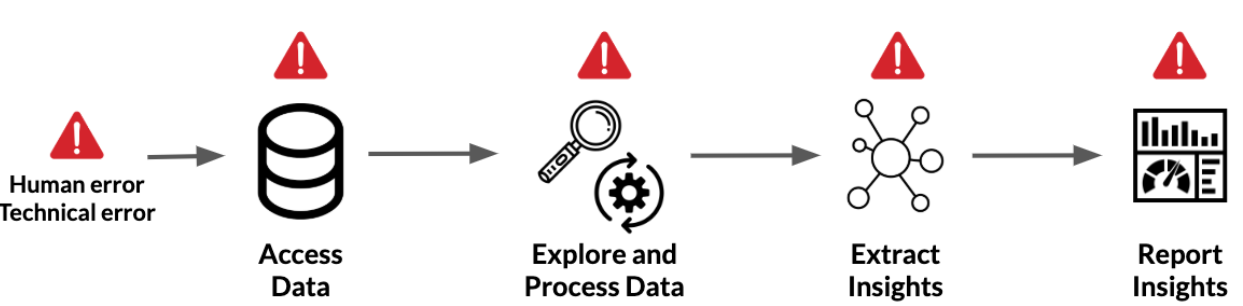

### **Common data types**

When working with new data, you should always check the data types of your columns using the
  * `.dtypes` attribute, or
  * `.info()` method

Often times, you'll run into columns that should be converted to different data types before starting any analysis.





## **Strings to Integers**

```
SalesOrderID    Revenue    Quantity
0   43659       23153$      12
1   43660        1457$       2
````

In [ ]:
sales = pd.read_csv('sales.csv')

# Remove $ from Revenue column
sales['Revenue'] = sales['Revenue'].str.strip('$')
sales['Revenue'] = sales['Revenue'].astype('int')

# Verify that Revenue is now an integer
assert sales['Revenue'].dtype == 'int'

## **Numerical or Categorical**

```
... marriage_status ...
              ... 3 ...
              ... 1 ...
              ... 2 ...
```

0 = Never married 1 = Married 2 = Separated 3 = Divorced

```
df['marriage_status'].describe()

marriage_status
...
mean        1.4
std         0.20
min         0.00
50%         1.8 ...
```
This is wrong

In [ ]:
# Convert to categorical
df["marriage_status"] = df["marriage_status"].astype('category')
df.describe()

```
marriage_status
count       241
unique        4
top           1
freq        120
```

### **Exercise: Numeric data or ... ?**

You'll be working with bicycle ride sharing data in San Francisco called `ride_sharing`. It contains information on the start and end stations, the trip duration, and some user information for a bike sharing service.

The `user_type` column contains information on whether a user is taking a free ride and takes on the following values:

* `1` for free riders.
* `2` for pay per ride.
* `3` for monthly subscribers.

In this instance, you will print the information of `ride_sharing` using `.info()` and see a firsthand example of **how an incorrect data type can flaw your analysis of the dataset.**

* Print the information of `ride_sharing`.
Use `.describe()` to print the summary statistics of the `user_type` column from `ride_sharing`.

In [ ]:
import pandas as pd

ride_sharing = pd.read_csv("ride_sharing_new.csv", index_col=[0])
print(ride_sharing.info(), "\n")

# Print summary statistics of user_type column
print(ride_sharing['user_type'].describe(), "\n")
print(ride_sharing['user_type'].value_counts())



<class 'pandas.core.frame.DataFrame'>
Index: 25760 entries, 0 to 25759
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   duration         25760 non-null  object
 1   station_A_id     25760 non-null  int64 
 2   station_A_name   25760 non-null  object
 3   station_B_id     25760 non-null  int64 
 4   station_B_name   25760 non-null  object
 5   bike_id          25760 non-null  int64 
 6   user_type        25760 non-null  int64 
 7   user_birth_year  25760 non-null  int64 
 8   user_gender      25760 non-null  object
 9   tire_sizes       25760 non-null  int64 
 10  ride_date        25760 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.4+ MB
None 

count    25760.000000
mean         2.008385
std          0.704541
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: user_type, dtype: float64 

user_type
2    12972
3     6502
1     6286
N


The `user_type` column has an finite set of possible values that represent groupings of data, it should be converted to `category`.

* Convert `user_type` into `categorical` by assigning it the `'category'` data type and store it in the `user_type_cat` column.
* Make sure you converted `user_type_cat` correctly by using an `assert` statement.

In [ ]:
import pandas as pd
ride_sharing = pd.read_csv("ride_sharing_new.csv", index_col=[0])

# Convert user_type from integer to category
ride_sharing['user_type_cat'] = ride_sharing['user_type'].astype("category")

# Write an assert statement confirming the change
assert ride_sharing['user_type_cat'].dtype == 'category'

# Print new summary statistics
print(ride_sharing['user_type_cat'].describe())

count     25760
unique        3
top           2
freq      12972
Name: user_type_cat, dtype: int64


### **Exercise: Summing strings and concatenating numbers**

You'll be converting the string column `duration` to the type `int`. Before that however, you will need to make sure to strip `"minutes"` from the column in order to make sure `pandas` reads it as numerical.

* Use the `.strip()` method to strip `duration` of `"minutes"` and store it in the `duration_trim `column.
* Convert `duration_trim` to `int` and store it in the `duration_time` column.
* Write an `assert` statement that checks if `duration_time`'s data type is now an `int`.
* Print the average ride duration.

In [ ]:
import pandas as pd
ride_sharing = pd.read_csv("ride_sharing_new.csv", index_col=[0])

# Strip duration of minutes
ride_sharing['duration_trim'] = ride_sharing['duration'].str.strip("minutes")

# Convert duration to integer
ride_sharing['duration_time'] = ride_sharing['duration_trim'].astype(int)

# Write an assert statement making sure of conversion
assert ride_sharing['duration_time'].dtype == 'int'

# Print formed columns and calculate average ride duration
print(ride_sharing[['duration','duration_trim','duration_time']].head(3))
print(ride_sharing['duration_time'].mean())

     duration duration_trim  duration_time
0  12 minutes           12              12
1  24 minutes           24              24
2   8 minutes            8               8
11.389052795031056


11 minutes is really not bad for an average ride duration in a city like San-Francisco. In the next lesson, you're going to jump right ahead into sanity checking the range of values in your data.

# **Data range constraints**

Example: rating takes only on the values 1, 2, 3, 4, 5

In [ ]:
movies = pd.read_csv('movies.csv')

plt.hist(movies['rating'])
plt.title('Average rating of movies (1-5)')

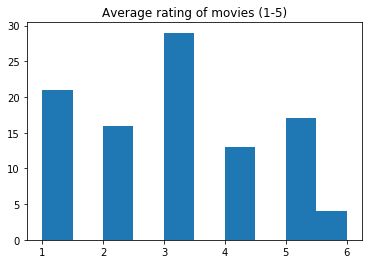

Example: Future sign-ups

In [ ]:
df = pd.read_csv('file.csv')
df[df['subscription_date'] > dt.date.today()]



```
subscription_date       user_name  ... Country
0 01/05/2021            Marah      ... Nauru
1 09/08/2020            Joshua     ... Austria
2 04/01/2020            Heidi      ... Guinea
3 11/10/2020            Rina       ... Turkmenistan
4 11/07/2020            Christine  ... Marshall Islands
5 07/07/2020            Ayanna     ... Gabon
```



## **How to deal with out of range data**

- Drop data if it is only a small proportion
- Set custom minimums and maximums
- Treat as missing and impute
- Setting custom value depending on business assumptions



### **Drop data**

In [ ]:
movies[movies['rating'] > 5]



```
        movie_name  avg_rating
23 A Beautiful Mind   6
65 La Vita e Bella    6
77 Amelie             6
```



In [ ]:
# Drop by filtering
movies = movies[movies['rating'] <= 5]

# Drop using .drop()
movies.drop(movies[movies['rating'] > 5].index, inplace=True)

# Assert result
assert movies['rating'].max() <= 5

### **Setting custom values**

In [ ]:
movies.loc[movies['rating'] > 5, 'rating'] = 5

## **Date range example**

In [ ]:
# Convert to date
df['subscription_date'] = pd.to_datetime(df['subscription_date']).dt.date

# drop by filtering
df = df[df['subscription_date'] < dt.date.today()]

# drop by .drop()
df.drop(df[df['subscription_date'] > dt.date.today()].index, inplace=True)

# set custom date to be today
df.loc[df['subscription_date'] > dt.date.today()] = dt.date.today()

assert df['subscription_date'].max().date() <= dt.date.today()

### **Exercise: Tire size constraints**

Bicycle tire sizes could be either 26″, 27″ or 29″ and are here correctly stored as a categorical value. In an effort to cut maintenance costs, the ride sharing provider decided to set the maximum tire size to be 27″.

You will make sure the `tire_sizes` column has the correct range by first converting it to an integer, then setting and testing the new upper limit of 27″ for tire sizes.

* Convert the `tire_sizes` column from category to `'int'`.
* Use `.loc[]` to set all values of `tire_sizes` above 27 to 27.
* Reconvert back `tire_sizes` to `'category'` from `int`
* Print the description of the `tire_sizes`

In [ ]:
import pandas as pd
ride_sharing = pd.read_csv("ride_sharing_new.csv", index_col=[0])

# Convert tire_sizes to integer
ride_sharing['tire_sizes'] = ride_sharing['tire_sizes'].astype('int')

# Set all values above 27 to 27
ride_sharing.loc[ride_sharing["tire_sizes"] > 27, "tire_sizes"] = 27

# Reconvert tire_sizes back to categorical
ride_sharing['tire_sizes'] = ride_sharing['tire_sizes'].astype("category")

# Print tire size description
print(ride_sharing['tire_sizes'].describe())

count     25760
unique        2
top          27
freq      13274
Name: tire_sizes, dtype: int64


You can look at the new maximum by looking at the `top` row in the description. Notice how essential it was to convert `tire_sizes` into integer before setting a new maximum.

### **Exercise: Back to the future**

A new update to the data pipeline feeding into the `ride_sharing` DataFrame has been updated to register each ride's date. This information is stored in the `ride_date` column of the type `object`, which represents strings in `pandas`.

A bug was discovered which was relaying rides taken today as taken next year. To fix this, you will find all instances of the `ride_date` column that occur anytime in the future, and set the maximum possible value of this column to today's date. Before doing so, you would need to convert `ride_date` to a `datetime` object.

### **Instructions**

* Convert `ride_date` to a `datetime` object and store it in `ride_dt` column using `to_datetime()`.
* Create the variable `today`, which stores today's date by using the `dt.date.today()` function.
* For all instances of `ride_dt `in the future, set them to today's date.
* Print the maximum date in the ride_dt column.

In [ ]:
assert(pd.to_datetime(ride_sharing['ride_date']).dt.date == pd.to_datetime(ride_sharing['ride_date'])).all()

In [ ]:
import pandas as pd
import datetime as dt
ride_sharing = pd.read_csv("ride_sharing_new.csv", index_col=[0])

# Convert ride_date to datetime
ride_sharing['ride_dt'] = pd.to_datetime(ride_sharing['ride_date'])

# Save today's date
today = dt.datetime.now()
# For some unknown reason, today = dt.date.today() cannot be used.

# Set all in the future to today's date
ride_sharing.loc[ride_sharing['ride_dt'] > today, 'ride_dt'] = today

# Print maximum of ride_dt column
print(ride_sharing['ride_dt'].max())

2022-09-14 00:00:00


Imagine counting the number of rides taken today without having cleaned your ranges correctly. You would have wildly underreported your findings!

# **Uniqueness constraints**

## **Duplicate values**

- All columns have the same values

```
+-----------+------------+----------------------+------------+-----------+
First name  | Last name  |      Address         |   Height   |  Weight   |
+-----------+------------+----------------------+------------+-----------+
Justin      | Smith      |Boulevard 3 Belmont VA|   193 cm   |  87kg     |
+-----------+------------+----------------------+------------+-----------+
Justin      | Smith      |Boulevard 3 Belmont VA|   193 cm   |  87kg     |
+-----------+------------+----------------------+------------+-----------+

```

- Most columns have the same values

```
+-----------+------------+----------------------+------------+-----------+
First name  | Last name  |      Address         |   Height   |  Weight   |
+-----------+------------+----------------------+------------+-----------+
Justin      | Smith      |Boulevard 3 Belmont VA|   193 cm   |  87kg     |
+-----------+------------+----------------------+------------+-----------+
Justin      | Smith      |Boulevard 3 Belmont VA|   197 cm   |  87kg     |
+-----------+------------+----------------------+------------+-----------+

```







## **How to find duplicate values**

In [ ]:
# Get duplicates across ALL columns
duplicates = df.duplicated()



```
1    False
...   ....
22   True
23   False
...   ...
```

## **How to find duplicate ROWS?**

Use **`.duplicated()`** method with additional two keyword arguments

- `subset=` : *List* of column names to check for duplicated values
- `keep=` : Whether to keep first (`'first'`), last (`'last'`), or all (`False`) duplicates

In [ ]:
duplicates = df.duplicated(subset=['col1', 'col2', 'col3'], keep=False)
df[duplicates].sort_values('col1') # Make duplicates more visible





## **Complete vs Incomplete Duplicates**

  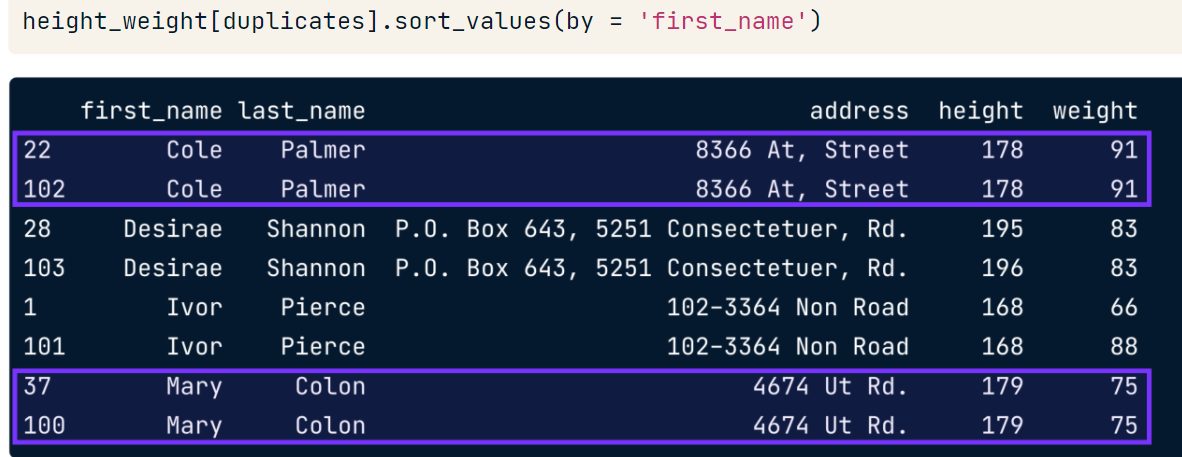

## **Incomplete Duplicates**

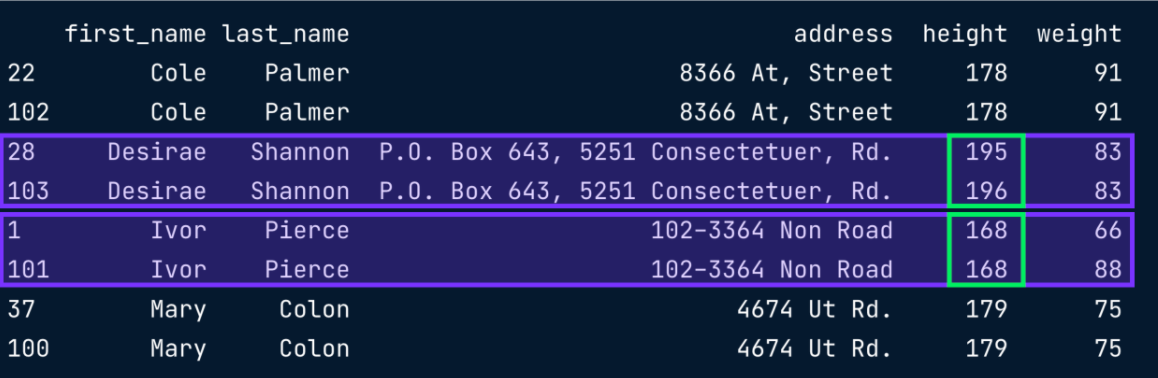






## **How to drop complete duplicates**

* Use **`.drop_duplicates()`** method

- `subset=` : List of columns to check for duplication
- `keep= `: Whether to keep first (`'first'`), last (`'last'`), or all (`False`) duplicates


## **How to drop incomplete duplicates**



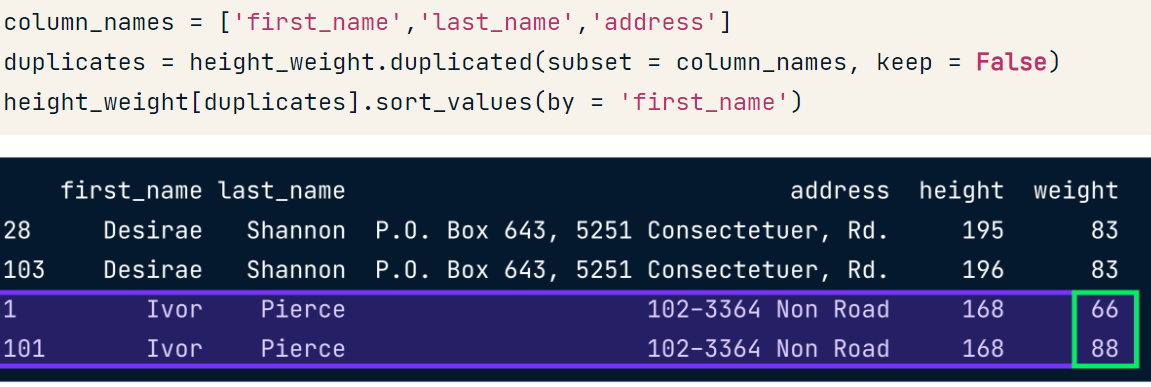



In [ ]:
# Aggregate duplicates using groupby
df = df.groupy(['first_name', 'last_name', 'address'])
       .agg({'height': 'max': 'weight': 'mean'})
       .reset_index()

## **Confirm that there is no duplicates left**

In [ ]:
duplicates = df.dupicated(subset=['first_name', 'last_name', 'address'], keep=False)

### **Exercise: How big is your subset?**

You have the following `loans` DataFrame which contains loan and credit score data for consumers, and some metadata such as their first and last names. You want to find both complete and incomplete duplicates using **`.duplicated()`**.

```
first_name	last_name	credit_score	has_loan
Justin	    Saddlemeyer	      600	    1
Hadrien	    Lacroix	          450   	0
```

- Using `loans.duplicated()` returns only the non-first complete duplicates across all columns.

- `loans.duplicated(subset = 'first_name')` is not appropriate as there are a lot of people with similar first names.

- `loans.duplicated(subset = ['first_name', 'last_name'], keep = 'first')`  drops cuplicated data so you cannot compare them.

The correct one is `loans.duplicated(subset = ['first_name', 'last_name'], keep=False)` because subsetting on consumer metadata and not discarding any duplicate returns all duplicated rows.  You can even subset the loans DataFrame using bracketing and sort the values so you can properly identify the duplicates.

### **Exercise: Finding duplicates**

A new update to the data pipeline feeding into `ride_sharing `has added the `ride_id` column, which represents a unique identifier for each ride.

The update however coincided with radically shorter average ride duration times and irregular user birth dates set in the future. Most importantly, the number of rides taken has increased by 20% overnight, leading you to think there might be both complete and incomplete duplicates in the `ride_sharing` DataFrame.

In this exercise, you will confirm this suspicion by finding those duplicates.

* Find duplicated rows of `ride_id` in the `ride_sharing` DataFrame while setting `keep` to `False`.
* Subset `ride_sharing` on duplicates and sort by `ride_id` and assign the results to `duplicated_rides`.
* Print the `ride_id`, `duration` and `user_birth_year` columns of `duplicated_rides` in that order.

In [ ]:
import pandas as pd
ride_sharing = pd.read_csv("ride_sharing_small_with_ride_id.csv", index_col=[0])

# Find duplicates
duplicates = ride_sharing.duplicated(subset="ride_id", keep=False)

# Sort your duplicated rides
duplicated_rides = ride_sharing[duplicates].sort_values(by='ride_id')

# Print relevant columns of duplicated_rides
print(duplicated_rides[['ride_id','duration','user_birth_year']])

    ride_id  duration  user_birth_year
22       33        10             1979
39       33         2             1979
53       55         9             1985
65       55         9             1985
74       71        11             1997
75       71        11             1997
76       89         9             1986
77       89         9             2060


Notice that rides `33` and `89` are incomplete duplicates, whereas the remaining are complete.

### **Exercise: Treating duplicates**

* Drop complete duplicates in `ride_sharing` and store the results in `ride_dup`.
* Create the `statistics` dictionary which holds **min**imum aggregation for `user_birth_year` and **mean** aggregation for `duration`.
* Drop incomplete duplicates by grouping by `ride_id` and applying the aggregation in `statistics`.
* Find duplicates again and run the `assert` statement to verify de-duplication.

In [ ]:
import pandas as pd
ride_sharing = pd.read_csv("ride_sharing_small_with_ride_id.csv", index_col=[0])

# Drop complete duplicates from ride_sharing
ride_dup = ride_sharing.drop_duplicates()

# Create statistics dictionary for aggregation function
statistics = {'user_birth_year': "min", 'duration': "mean"}

# Group by ride_id and compute new statistics
ride_unique = ride_dup.groupby('ride_id').agg(statistics).reset_index()

# Find duplicated values again
duplicates = ride_unique.duplicated(subset='ride_id', keep=False)
duplicated_rides = ride_unique[duplicates]

# Assert duplicates are processed
assert duplicated_rides.shape[0] == 0

# **Categorical Constraints**

```
Type of data                Example values          Numeric representation
Marriage Status             unmarried , married        0 , 1
Household Income Category   0-20K , 20-40K , ...       0 , 1 , ..
Loan Status                 default , payed , no_loan  0 , 1 , 2
```
Values cannot be outside finite set of values, e.g., marriage status cannot be something else other than unmarried and married.

- Drop the rows with incorrect categories
- Mapping incorrect categories to be one of the correct values


## **Inconsistencies**

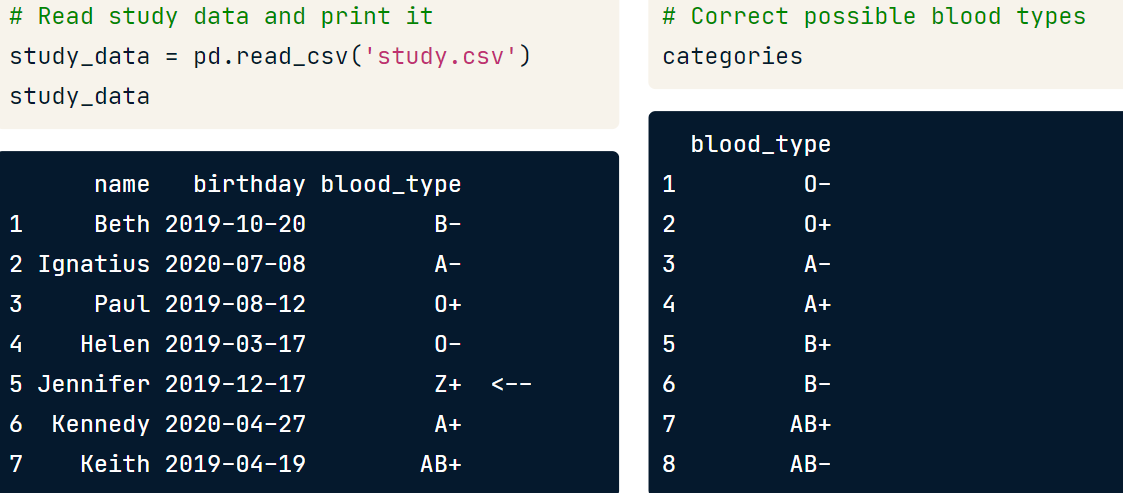



## **Aside on joins**

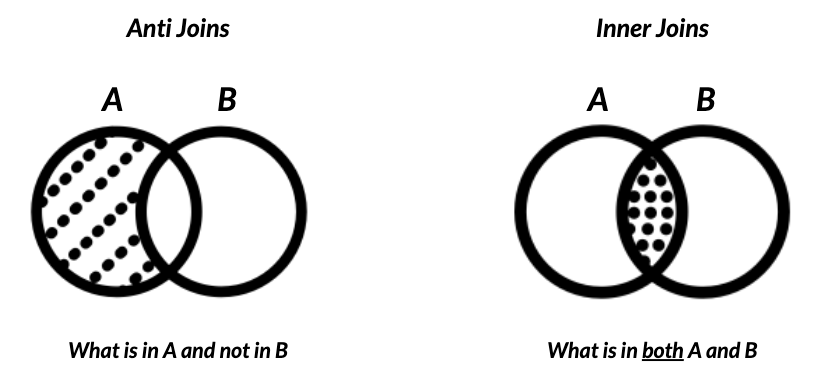

## **A left anti-join on blood types**

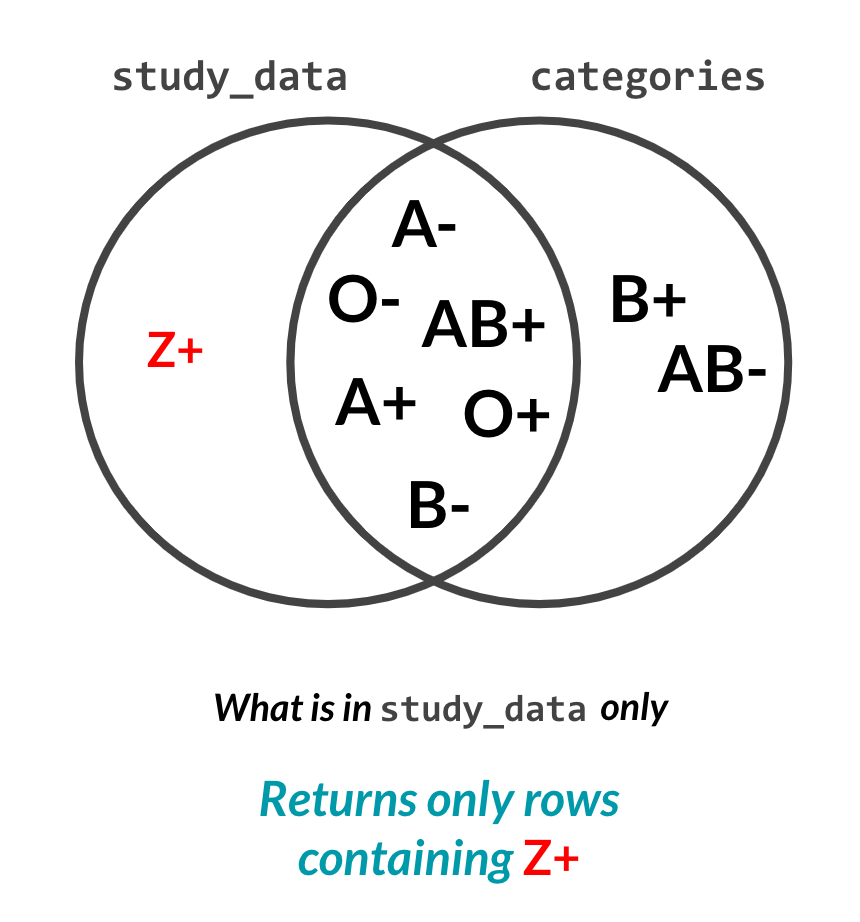

## **Finding inconsistent categories**

In [ ]:
inconsistent_categories = set(study_data['blood_type']).difference(categories['blood_type'])



```
{'Z+'}
```



In [ ]:
# Get rows with inconsistency
inconsistent_rows = study_data['blood_type'].isin(inconsistent_categories)
study_data[inconsistent_rows]

## **Drop inconsistent categories**

In [ ]:
consistent_data = study_data[~inconsistent_rows]

### **Exercise: Finding consistency**

* Print the `categories` DataFrame and take a close look at all possible correct categories of the survey columns.
* Print the unique values of the survey columns in airlines using the `.unique()` method.

In [ ]:
import pandas as pd
airlines = pd.read_csv("airlines_final.csv", index_col=[0])

# เปลี่ยนให้ข้อมูลเป็นตามโจทย์
airlines.loc[[4, 18, 100], "cleanliness"] = "Unacceptable"
cat = {'cleanliness':['Clean', 'Average', 'Somewhat clean', 'Somewhat dirty', 'Dirty'],
       'safety':['Neutral', 'Very safe', 'Somewhat safe', 'Very unsafe', 'Somewhat unsafe'],
       'satisfaction': ['Very satisfied', 'Neutral', 'Somewhat satisfied', 'Somewhat unsatisfied','Very unsatisfied']}
categories = pd.DataFrame(data=cat)

# Print categories DataFrame
print(categories,"\n\n")

# Print unique values of survey columns in airlines
print('Cleanliness: ', airlines['cleanliness'].unique(), "\n")
print('Safety: ', airlines["safety"].unique(), "\n")
print('Satisfaction: ', airlines["satisfaction"].unique(), "\n")


      cleanliness           safety          satisfaction
0           Clean          Neutral        Very satisfied
1         Average        Very safe               Neutral
2  Somewhat clean    Somewhat safe    Somewhat satisfied
3  Somewhat dirty      Very unsafe  Somewhat unsatisfied
4           Dirty  Somewhat unsafe      Very unsatisfied 


Cleanliness:  ['Clean' 'Average' 'Unacceptable' 'Somewhat clean' 'Somewhat dirty'
 'Dirty'] 

Safety:  ['Neutral' 'Very safe' 'Somewhat safe' 'Very unsafe' 'Somewhat unsafe'] 

Satisfaction:  ['Very satisfied' 'Neutral' 'Somewhat satsified' 'Somewhat unsatisfied'
 'Very unsatisfied'] 



Out of the cleanliness, safety and satisfaction columns, `cleanliness` has inconsistencies because it has an `Unacceptable` category.

* Create a set out of the `cleanliness` column in `airlines` using `set()` and find the inconsistent category by finding the **difference** in the `cleanliness` column of `categories`.
* Find rows of `airlines` with a `cleanliness` value not in `categories` and print the output.
* Print the rows with the consistent categories of `cleanliness` only.

In [ ]:
import pandas as pd
pd.set_option("display.max_columns", None)
airlines = pd.read_csv("airlines_final.csv", index_col=[0])
airlines.loc[[4, 18, 100], "cleanliness"] = "Unacceptable" # เปลี่ยนให้ข้อมูลเป็นตามโจทย์
cat = {'cleanliness':['Clean', 'Average', 'Somewhat clean', 'Somewhat dirty', 'Dirty'],
       'safety':['Neutral', 'Very safe', 'Somewhat safe', 'Very unsafe', 'Somewhat unsafe'],
       'satisfaction': ['Very satisfied', 'Neutral', 'Somewhat satisfied', 'Somewhat unsatisfied','Very unsatisfied']}
categories = pd.DataFrame(data=cat)

# Find the cleanliness category in airlines not in categories
cat_clean = set(airlines["cleanliness"]).difference(set(categories["cleanliness"]))

# Find rows with that category
cat_clean_rows = airlines['cleanliness'].isin(cat_clean)

# Print rows with inconsistent category
print(airlines[cat_clean_rows]['cleanliness'], "\n")

# Print rows with consistent categories only
print(airlines[~cat_clean_rows]['cleanliness'])

4      Unacceptable
18     Unacceptable
100    Unacceptable
Name: cleanliness, dtype: object 

0                Clean
1                Clean
2              Average
3                Clean
5       Somewhat clean
             ...      
2804    Somewhat clean
2805             Clean
2806             Clean
2807             Clean
2808             Clean
Name: cleanliness, Length: 2474, dtype: object


In the next lesson, we'll be looking at more in depth solutions to dealing with dirty categorical data.

# **Categorical Variables**



## **Value consistency**

 - ***Capitalization***: `'married'` , `'Married'` , `'UNMARRIED'` , `'unmarried'`

     - Use **`.str.lower()`** or **`.str.upper()`**

 - ***Trailing spaces***: `'married '` , `'married'` , `'unmarried'` , `' unmarried'`

     - Use **`.str.strip()`**

### **Collapse too many categories**: e.g. `income_group` from `income` column

- Creating new groups: `0-20K`, `20-40K`, ... from continuous household data
      - Use **`pd.qcut()`**
- Mapping groups to new ones, e.g., `rich`, `poor`

In [ ]:
df['income_group'] = pd.qcut(df['household_income'], q=3, labels=['0-200K', '200K-500K', '500K+'])

```
    category    household_income
0   200K-500K       189243
1   500K+           778533
...
```
- Notice that the first row misrepresent the income group because 189,243 < 200K

- **`pd.qcut()`** น่าจะแบ่งตาม quantile ซึ่งค่าที่กำหนดน่าจะมาจาก q ถ้าจะแบ่งเองใช้ **`pd.cut()`** ดีกว่า

In [ ]:
ranges = [0,200000,500000,np.inf]
group_names = ['0-200K', '200K-500K', '500K+']
df['income_group'] = pd.cut(df['household_income'], bins=ranges, labels=group_names)

### ***Map categories to fewer ones***:

Original groups: A1, A2, B1, B2

Want: A, B

- Use **`.replace(mapping_dict)`**

In [ ]:
df['want'] = df['original'].replace({'A1':'A', 'A2':'A', 'B1':'B', 'B2', 'B'})

### **Exercise: Inconsistent categories**

As a reminder, the DataFrame contains flight metadata such as the airline, the destination, waiting times as well as answers to key questions regarding cleanliness, safety, and satisfaction on the San Francisco Airport.

Examine two categorical columns from `airlines` dataframe, `dest_region` and `dest_size` respectively, assess how to address them and make sure that they are cleaned and ready for analysis.

* Print the unique values in `dest_region` and `dest_size` respectively.

In [ ]:
import pandas as pd
pd.set_option("display.max_columns", None)
airlines = pd.read_csv("airlines_final.csv", index_col=[0])

# Print unique values of both columns
print(airlines['dest_region'].unique(), "\n")
print(airlines['dest_size'].unique())

['Asia' 'Canada/Mexico' 'West US' 'East US' 'Midwest US' 'EAST US'
 'Middle East' 'Europe' 'eur' 'Central/South America'
 'Australia/New Zealand' 'middle east'] 

['Hub' 'Small' '    Hub' 'Medium' 'Large' 'Hub     ' '    Small'
 'Medium     ' '    Medium' 'Small     ' '    Large' 'Large     ']


* The `dest_region` column has inconsistent values due to capitalization and has one value that needs to be remapped.
* The `dest_size` column has only inconsistent values due to leading and trailing spaces.

--------------------------------------------------------------
* Change the capitalization of all values of `dest_region` to lowercase.
* Replace the `'eur'` with `'europe'` in `dest_region` using the `.replace()` method.
* Strip white spaces from the `dest_size` column using the `.strip()` method.
* Verify that the changes have been into effect by printing the unique values of the columns using `.unique()`.

In [ ]:
import pandas as pd
pd.set_option("display.max_columns", None)
airlines = pd.read_csv("airlines_final.csv", index_col=[0])

# Lower dest_region column and then replace "eur" with "europe"
airlines['dest_region'] = airlines['dest_region'].str.lower()
airlines['dest_region'] = airlines['dest_region'].replace({'eur':'europe'})

# Remove white spaces from `dest_size`
airlines['dest_size'] = airlines['dest_size'].str.strip()

# Verify changes have been effected
print(airlines['dest_region'].unique(), "\n")
print(airlines['dest_size'].unique())

['asia' 'canada/mexico' 'west us' 'east us' 'midwest us' 'middle east'
 'europe' 'central/south america' 'australia/new zealand'] 

['Hub' 'Small' 'Medium' 'Large']


### **Exercise: Remapping categories**

The `airlines` DataFrame contains the `day` and `wait_min` columns, which are categorical and numerical respectively. The day column contains the exact `day` a flight took place, and `wait_min` contains the amount of minutes it took travelers to wait at the gate. To make your analysis easier, you want to create two new categorical variables:

* `wait_type`:
  * `'short'` for 0-60 min
  * `'medium'` for 60-180 min
  * `'long'` for 180+
* `day_week`:
  * `'weekday'` if day is in the weekday,
  * `'weekend'` if day is in the weekend.
---------------------------------------------------------------

##### ***Instructions***

* Create the ranges and labels for the `wait_type` column mentioned in the description above.
* Create the `wait_type` column from `wait_min` by using `pd.cut()`, while inputting `label_ranges` and `label_names` in the correct arguments.
* Create the `mapping` dictionary mapping weekdays to `'weekday'` and weekend days to `'weekend'`.
* Create the `day_week` column by using `.replace()`.

In [ ]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
airlines = pd.read_csv("airlines_final.csv", index_col=[0])

# Create ranges for categories
label_ranges = [0, 60, 180, np.inf]
label_names = ['short', "medium", "long"]

# Create wait_type column
airlines['wait_type'] = pd.cut(airlines["wait_min"], bins=label_ranges, labels=label_names)

# Create mappings and replace
mappings = {'Monday':'weekday', 'Tuesday':'weekday', 'Wednesday': 'weekday', 'Thursday': 'weekday', 'Friday': 'weekday',
            'Saturday': 'weekend', 'Sunday': 'weekend'}

airlines['day_week'] = airlines['day'].replace(mappings)
airlines[["day", "wait_min", "day_week", "wait_type"]].head()

,day,wait_min,day_week,wait_type
0,Tuesday,115.0,weekday,medium
1,Friday,135.0,weekday,medium
2,Thursday,70.0,weekday,medium
3,Tuesday,190.0,weekday,long
4,Wednesday,559.0,weekday,long


You just created two new categorical variables, that when combined with other columns, could produce really interesting analysis. Don't forget, you can always use an **`assert`** statement to check your changes passed.

# **Cleaning Text Data**

1) Data format inconsistency
    - `+96171679912` or `0096171679912` or ..?
2) Fixed length violations, e.g., length of password

3) Typos

## **Phone numbers**

```
   Full name              Phone number
0  Noelani A. Gray        001-702-397-5143
1  Myles Z. Gomez         001-329-485-0540
2  Gil B. Silva           001-195-492-2338
3  Prescott D. Hardin     +1-297-996-4904   <-- Inconsistent data format
4  Benedict G. Valdez     001-969-820-3536
5  Reece M. Andrews       4138              <-- Length violation
6  Hayfa E. Keith         001-536-175-8444
7  Hedley I. Logan        001-681-552-1823
8  Jack W. Carrillo       001-910-323-5265
9  Lionel M. Davis        001-143-119-9210
```
We want to make change to be the same format



In [ ]:
df['Phone number'] = df['Phone number'].str.replace('+', '00')
df['Phone number'] = df['Phone number'].str.replace('-', '')
df.loc[df['Phone number'].str.len()<10, 'Phone number'] = np.nan
assert df['Phone number'].str.len() >= 10
assert df['Phone number'].str.contains('+|-').any() == False

```
   Full name              Phone number
0  Noelani A. Gray        0017023975143
1  Myles Z. Gomez         0013294850540
2  Gil B. Silva           0011954922338
3  Prescott D. Hardin     0012979964904
4  Benedict G. Valdez     0019698203536
5  Reece M. Andrews       NaN
6  Hayfa E. Keith         0015361758444
7  Hedley I. Logan        0016815521823
8  Jack W. Carrillo       0019103235265
9  Lionel M. Davis        0011431199210
```

## **More messy text**
```text
   Full name            Phone number
0  Olga Robinson        +(01706)-25891
1  Justina Kim          +0500-571437
2  Tamekah Henson       +0800-1111
3  Miranda Solis        +07058-879063
4  Caldwell Gilliam     +(016977)-8424
```

`r'\D+'` เป็น regular expression (regex) ที่มีความหมายดังนี้

- `r'...'` = raw string ใน Python ทำให้ `\` ถูกตีความเป็นตัวอักษร backslash จริง ๆ ไม่ใช่ escape character มีความหมายว่า "ไม่"
- `\D` = อักขระที่ไม่ใช่ตัวเลข (non-digit) เทียบเท่ากับ `[^0-9]`
- `+` = หนึ่งตัวขึ้นไป (one or more)

In [ ]:
df['Phone number'] = df['Phone numer'].str.replace(r'\D+', '', regex=True)

| เดิม             | หลัง replace |
| ---------------- | ------------ |
| `+(01706)-25891` | `0170625891` |
| `+0500-571437`   | `0500571437` |
| `(123) 456-7890` | `1234567890` |

เพราะ `\D+` จะจับ

- `+`
- `(`
- `)`
- `-`
- `ช่องว่าง`
- `ตัวอักษร`

แล้วแทนที่ด้วย `''` (สตริงว่าง)

```text
   Full name            Phone number
0  Olga Robinson         0170625891
1  Justina Kim           0500571437
2  Tamekah Henson          08001111
3  Miranda Solis        07058879063
4  Caldwell Gilliam      0169778424
```

### **Exercise: Removing titles and taking names**

While collecting survey respondent metadata in the `airlines` DataFrame, the full name of respondents was saved in the `full_name` column. However upon closer inspection, you found that a lot of the different names are prefixed by honorifics such as `"Dr."`, `"Mr."`, `"Ms."` and `"Miss"`.

You are to create two new columns named `first_name` and `last_name`, containing the first and last names of respondents respectively. Before doing so however, you need to remove honorifics.

* Remove `"Dr."`, `"Mr."`, `"Miss"` and `"Ms."` from `full_name` by replacing them with an empty string `""` in that order.
* Run the `assert` statement using `.str.contains()` that tests whether `full_name` still contains any of the honorifics.

In [ ]:
import pandas as pd
airlines = pd.read_csv("airlines_small_with_fullname.csv", index_col=[0])

airlines['full_name'] = airlines['full_name'].str.replace(r'Dr\.|Mr\.|Miss|Ms\.',"", regex=True)
assert airlines['full_name'].str.contains('Ms.|Mr.|Miss|Dr.').any() == False

# Create two new columns (โจทย์ไม่ได้มีบอกให้ทำ)
airlines["full_name"] = airlines["full_name"].str.strip()
airlines[["first_name", "last_name"]] = airlines["full_name"].str.split(" ", expand=True) # ถ้าจำนวนช่องว่างไม่เท่ากัน ใช้ r"\s+"
airlines.drop("full_name", axis=1, inplace=True)

# Reorder columns
airlines = airlines[['id', 'first_name', 'last_name', 'day', 'airline', 'destination', 'dest_region', 'dest_size', 'boarding_area', 'dept_time', 'wait_min', 'cleanliness', 'safety', 'satisfaction']]
print(airlines[["id", "first_name", "last_name", "day", 'airline', 'destination']].head())

     id             full_name        day      airline        destination  \
0  1351        Melodie Stuart    Tuesday  UNITED INTL             KANSAI   
1   373       Dominic Shannon     Friday       ALASKA  SAN JOSE DEL CABO   
2  2820     Quintessa Tillman   Thursday        DELTA        LOS ANGELES   
3  1157   Christine Nicholson    Tuesday    SOUTHWEST        LOS ANGELES   
4  2992       Regina Clements  Wednesday     AMERICAN              MIAMI   

     dest_region dest_size boarding_area   dept_time  wait_min  \
0           Asia       Hub  Gates 91-102  2018-12-31     115.0   
1  Canada/Mexico     Small   Gates 50-59  2018-12-31     135.0   
2        West US       Hub   Gates 40-48  2018-12-31      70.0   
3        West US       Hub   Gates 20-39  2018-12-31     190.0   
4        East US       Hub   Gates 50-59  2018-12-31     559.0   

      cleanliness         safety        satisfaction  
0           Clean        Neutral      Very satisfied  
1           Clean      Very safe    

### **Exercise: Keeping it descriptive**

* Using the `airlines` DataFrame, store the length of each instance in the `survey_response` column in `resp_length` by using `.str.len()`.
* Isolate the rows of `airlines` with `resp_length` higher than `40`.
* Assert that the smallest `survey_response` length in `airlines_survey` is now bigger than `40`.

In [ ]:
import pandas as pd
airlines = pd.read_csv("airlines_final.csv", index_col=[0])

# เปลี่ยนข้อมูลให้เหมือนโจทย์
airlines = airlines.head(29)
airlines["cleanliness"], airlines["safety"], airlines["satisfaction"] = "Dirty", "Very unsafe", "Very unsatisfied"
airlines["survey_response"] = ['It was terrible', "I didn't like the flight", 'I hate this ',
       'Not a fan', 'Bad', 'Horrible', 'Very poor', 'Unacceptable flight',
       'It was awful', 'My fllight was really unpleasant',
       'I am not a fan', 'I had a bad flight', 'It was very bad',
       'it was horrible', 'Terrible', 'It was substandard',
       'I did not enjoy the flight',
       'The airport personnell forgot to alert us of delayed flights, the bathrooms could have been cleaner',
       'The food in the airport was really really expensive - also no automatic escalators!',
       'One of the other travelers was really loud and talkative and was making a scene and no one did anything about it',
       "I don't remember answering the survey with these scores, my experience was great! ",
       'The airport personnel kept ignoring my requests for directions ',
       'The chair I sat in was extremely uncomfortable, I still have back pain to this day! ',
       'I wish you were more like other airports, the flights were really disorganized! ',
       'I was really unsatisfied with the wait times before the flight. It was unacceptable.',
       "The flight was okay, but I didn't really like the number of times I had to stop at security",
       'We were really slowed down by security measures, I missed my flight because of it! ',
       'There was a spill on the aisle next to the bathroom and it took hours to clean!',
       'I felt very unsatisfied by how long the flight took to take off.']

# Store length of each row in survey_response column
resp_length = airlines["survey_response"].str.len()

# Find rows in airlines where resp_length > 40
airlines_survey = airlines[resp_length > 40]

# Assert minimum survey_response length is > 40
assert airlines_survey["survey_response"].str.len().min() > 40

# Print new survey_response column
print(airlines_survey['survey_response'])


18    The airport personnell forgot to alert us of d...
19    The food in the airport was really really expe...
20    One of the other travelers was really loud and...
21    I don't remember answering the survey with the...
22    The airport personnel kept ignoring my request...
23    The chair I sat in was extremely uncomfortable...
24    I wish you were more like other airports, the ...
25    I was really unsatisfied with the wait times b...
27    The flight was okay, but I didn't really like ...
28    We were really slowed down by security measure...
29    There was a spill on the aisle next to the bat...
30    I felt very unsatisfied by how long the flight...
Name: survey_response, dtype: object


# **Uniformity**

```text
Column        Unit
Temperature   32°C is also 89.6°F
Weight        70 Kg is also 11 st.
Date          26-11-2019 is also 26, November, 2019
Money         100$ is also 10763.90¥
```

#### **Temperature data**

```
      Date Temperature
0 03.03.19    14.0
1 04.03.19    15.0
2 05.03.19    18.0
3 06.03.19    16.0
4 07.03.19    62.6  <====== Most likely Farenheit, not Celcius
...
```


In [ ]:
fah = df.loc[df['Temperature'] > 40, 'Temperature']
df.loc[df['Temperature'] > 40, 'Temperature'] = (fah - 32) * (5/9)
assert df['Temperature'].max() < 40

## **Treating Date Data**

```text
             Birthday First name Last name
0            27/27/19      Rowan      Nunez   ??
1            03-29-19      Brynn       Yang   MM-DD-YY
2     March 3rd, 2019     Sophia     Reilly   Month D, YYYY
3            24-03-19     Deacon     Prince   DD-MM-YY
4            06-03-19   Griffith       Neal   ??
```

```
Date                    format
25-12-2020            %d-%m-%Y
December 25th 2020      %c
12-25-2020            %m-%d-%Y
```

In [ ]:
# Converts to datetime - but won't work if column contains various formats
df['Birthday'] = pd.to_datetime(df['Birthday'])

# If above does not work, use this
df['Birthday'] = pd.to_datetime(df['Birthday'], infer_datetime_format=True, errors='coerce')
# errors='coerce' return NA for rows where conversion failed

```
      Birthday    First name      Last name
0       NaT         Rowan         Nunez
1   2019-03-29      Brynn         Yang
2   2019-03-03      Sophia        Reilly
3   2019-03-24      Deacon        Prince
4   2019-06-03      Griffith      Neal
```

## **`strftime`** (String From Time)

- ใช้แปลง `datetime` ให้เป็นข้อความตาม format ที่ต้องการ

In [ ]:
df['Birthday'] = df['Birthday'].dt.strftime("%d-%m-%Y")

```
      Birthday    First name      Last name
0       NaT         Rowan         Nunez
1   29-03-2019      Brynn         Yang
2   03-03-2019      Sophia        Reilly
3   24-03-2019      Deacon        Prince
4   03-06-2019      Griffith      Neal
```

### **Exercise: Uniform currencies**

The dataset contains data on the amount of money stored in accounts (`acct_amount`), their currency (`acct_cur`), amount invested (`inv_amount`), account opening date (`account_opened`), and last transaction date (`last_transaction`) that were consolidated from American and European branches.

* Find the rows of `acct_cur` in `banking` that are equal to `'euro'` and store them in the variable `acct_eu`.
* Find all the rows of `acct_amount` in `banking` that fit the `acct_eu` condition, and convert them to USD by multiplying them with `1.1`.
* Find all the rows of `acct_cur` in banking that fit the `acct_eu` condition, set them to `'dollar'`.

In [ ]:
import pandas as pd
banking = pd.read_csv("banking_with_currency.csv", index_col=[0])[['cust_id', 'acct_amount', 'acct_cur', 'inv_amount', 'account_opened', 'last_transaction']]
print(banking.head(), "\n")

# Find values of acct_cur that are equal to 'euro'
acct_eu = banking['acct_cur'] == 'euro'

# Convert acct_amount where it is in euro to dollars
banking.loc[acct_eu, 'acct_amount'] = banking.loc[acct_eu, 'acct_amount'] * 1.1

# Unify acct_cur column by changing 'euro' values to 'dollar'
banking.loc[acct_eu, 'acct_cur'] = 'dollar'

# Assert that only dollar currency remains
assert banking['acct_cur'].unique() == 'dollar'

print(banking.head())

    cust_id  acct_amount acct_cur  inv_amount account_opened last_transaction
0  8C35540A     44244.71   dollar    35500.50       03-05-18         30-09-19
1  D5536652     86506.85   dollar    81921.86       21-01-18         14-01-19
2  A631984D     77799.33   dollar    46412.27       26-01-18         06-10-19
3  93F2F951     93875.24     euro    76563.35       21-08-17         10-07-19
4  DE0A0882     99998.35     euro    18669.01       05-06-17         15-01-19 

    cust_id  acct_amount acct_cur  inv_amount account_opened last_transaction
0  8C35540A    44244.710   dollar    35500.50       03-05-18         30-09-19
1  D5536652    86506.850   dollar    81921.86       21-01-18         14-01-19
2  A631984D    77799.330   dollar    46412.27       26-01-18         06-10-19
3  93F2F951   103262.764   dollar    76563.35       21-08-17         10-07-19
4  DE0A0882   109998.185   dollar    18669.01       05-06-17         15-01-19


### **Exercise: Uniform dates**

 The `account_opened` column represents when customers opened their accounts. You need to make sure that all dates are of the same format. You will do so by converting this column into a `datetime` object, while making sure that the format is inferred and potentially incorrect formats are set to missing.

* Print the header of `account_opened` from the banking DataFrame and take a look at the different results.



In [ ]:
import pandas as pd
banking = pd.read_csv("banking_with_currency.csv", index_col=[0])[['cust_id', 'acct_amount', 'acct_cur', 'inv_amount', 'account_opened', 'last_transaction']]
acct_eu = banking['acct_cur'] == 'euro'
banking.loc[acct_eu, 'acct_amount'] = banking.loc[acct_eu, 'acct_amount'] * 1.1
banking.loc[acct_eu, 'acct_cur'] = 'dollar'

# เปลี่ยนวันที่ ให้เหมือนโจทย์
banking["account_opened"] = ['2018-03-05', '21-01-18', 'January 26, 2018', '21-14-17',
       '05-06-17', '26-12-17', '21-06-18', '07-10-17', '02-09-18',
       '28-02-19', '15-06-18', '03-01-19', '03-02-18', '15-08-18',
       '04-06-17', '26-05-18', '14-12-18', '03-09-18', '10-08-18',
       '23-02-19', '02-05-18', '04-05-17', '14-05-18', '16-05-17',
       '29-01-19', '03-04-18', '04-02-19', '03-01-19', '28-02-18',
       '29-12-18', '05-12-17', '29-07-18', '09-10-18', '30-10-18',
       '12-03-18', '28-01-19', '13-11-17', '23-07-18', '18-07-17',
       '20-04-18', '09-10-17', '22-01-18', '08-06-17', '17-09-18',
       '03-04-17', '09-08-18', '23-05-18', '18-10-18', '17-03-17',
       '30-12-18', '18-08-18', '02-07-17', '27-04-18', '07-11-17',
       '06-02-18', '28-09-18', '28-04-18', '08-03-18', '18-10-18',
       '25-02-18', '17-09-18', '09-06-18', '28-11-17', '09-05-18',
       '26-02-19', '29-05-18', '25-04-18', '15-12-18', '30-08-18',
       '16-08-17', '27-12-18', '16-09-17', '01-08-17', '08-06-17',
       '27-10-18', '04-06-17', '05-02-18', '06-05-18', '20-03-18',
       '22-05-17', '30-12-18', '17-11-17', '14-04-17', '20-04-17',
       '08-08-18', '19-05-18', '24-12-17', '07-11-17', '16-11-17',
       '08-12-18', '09-02-19', '10-04-18', '26-11-17', '14-07-18',
       '02-06-18', '28-05-17', '23-10-17']

# Print the header of account_opened
print(banking["account_opened"].head())
pd.to_datetime(banking["account_opened"])


0          2018-03-05
1            21-01-18
2    January 26, 2018
3            21-14-17
4            05-06-17
Name: account_opened, dtype: object


ParserError: ignored

You tried converting the values to datetime using the default `to_datetime()` function without changing any argument, however received the above error.  This is because the `21-14-17` entry is erroneous and leads to an error.

* Convert the `account_opened` column to `datetime`, while making sure the date format is inferred and that erroneous formats that raise error return a missing value.
* Extract the year from the amended `account_opened` column and assign it to the `acct_year` column.
* Print the newly created `acct_year` column.

In [ ]:
import pandas as pd
banking = pd.read_csv("banking_with_currency.csv", index_col=[0])[['cust_id', 'acct_amount', 'acct_cur', 'inv_amount', 'account_opened', 'last_transaction']]
acct_eu = banking['acct_cur'] == 'euro'
banking.loc[acct_eu, 'acct_amount'] = banking.loc[acct_eu, 'acct_amount'] * 1.1
banking.loc[acct_eu, 'acct_cur'] = 'dollar'

# เปลี่ยนวันที่ ให้เหมือนโจทย์
banking["account_opened"] = ['2018-03-05', '21-01-18', 'January 26, 2018', '21-14-17',
       '05-06-17', '26-12-17', '21-06-18', '07-10-17', '02-09-18',
       '28-02-19', '15-06-18', '03-01-19', '03-02-18', '15-08-18',
       '04-06-17', '26-05-18', '14-12-18', '03-09-18', '10-08-18',
       '23-02-19', '02-05-18', '04-05-17', '14-05-18', '16-05-17',
       '29-01-19', '03-04-18', '04-02-19', '03-01-19', '28-02-18',
       '29-12-18', '05-12-17', '29-07-18', '09-10-18', '30-10-18',
       '12-03-18', '28-01-19', '13-11-17', '23-07-18', '18-07-17',
       '20-04-18', '09-10-17', '22-01-18', '08-06-17', '17-09-18',
       '03-04-17', '09-08-18', '23-05-18', '18-10-18', '17-03-17',
       '30-12-18', '18-08-18', '02-07-17', '27-04-18', '07-11-17',
       '06-02-18', '28-09-18', '28-04-18', '08-03-18', '18-10-18',
       '25-02-18', '17-09-18', '09-06-18', '28-11-17', '09-05-18',
       '26-02-19', '29-05-18', '25-04-18', '15-12-18', '30-08-18',
       '16-08-17', '27-12-18', '16-09-17', '01-08-17', '08-06-17',
       '27-10-18', '04-06-17', '05-02-18', '06-05-18', '20-03-18',
       '22-05-17', '30-12-18', '17-11-17', '14-04-17', '20-04-17',
       '08-08-18', '19-05-18', '24-12-17', '07-11-17', '16-11-17',
       '08-12-18', '09-02-19', '10-04-18', '26-11-17', '14-07-18',
       '02-06-18', '28-05-17', '23-10-17']

# Print the header of account_opend
print(banking['account_opened'].head(), "\n")

# Convert account_opened to datetime
banking['account_opened'] = pd.to_datetime(banking['account_opened'],
                                           # Infer datetime format
                                           infer_datetime_format=True,
                                           # Return missing value for error
                                           errors='coerce')

# Get year of account opened
banking['acct_year'] = banking['account_opened'].dt.strftime('%Y')

# Print acct_year
print(banking['acct_year'].head())

0          2018-03-05
1            21-01-18
2    January 26, 2018
3            21-14-17
4            05-06-17
Name: account_opened, dtype: object 

0    2018
1    2018
2    2018
3     NaN
4    2017
Name: acct_year, dtype: object


Now that the `acct_year` column is created, a simple **`.groupby()`** will show you how accounts are opened on a yearly.

# **Cross field validation**

The use of *multiple columns* to inspect whether data are consistent across dataframe.

In an example below, it performs a check for total passengers must equal every passengers from all other parts.



```
```text
  flight_number  economy_class  business_class  first_class  total_passengers
0         DL140            100 +             60 +          40 =               200
1         BA248            130 +            100 +          70 =               300
2        MEA124            100 +             50 +          50 =               200
3        AFR939            140 +             70 +          90 =               300
4        TKA101            130 +            100 +          20 =               250
```

In [ ]:
sum_classes = df[['economy_class', 'business_class', 'first_class']].sum(axis = 1)

# Find and filter out rows with inconsistent passenger totals
inconsistent_pass = df[~(sum_classes==df['total_passengers'])]
consistent_pass = df[sum_classes==df['total_passengers']]

## **Date Validation**

- Subtract the number of years between today's date and each birthday must equal age

```text
   user_id  Age    Birthday
0    32985   22  1998-03-02
1    94387   27  1993-12-04
2    34236   42  1978-11-24
3    12551   31  1989-01-03
4    55212   18  2002-07-02
```

In [ ]:
import pandas as pd
import datetime as dt

# Convert to datetime and get today's date
df['Birthday'] = pd.to_datetime(df['Birthday'])
today = dt.date.today()

# For each row in the Birthday column, calculate year difference
age_manual = today.year - df['Birthday'].dt.year

# Find and filter out rows with inconsistent age
inconsistent_age = df[~(age_manual==df['Age'])]
consistent_age = df[(age_manual==df['Age'])]

## **What to do when we catch inconsistencies?**

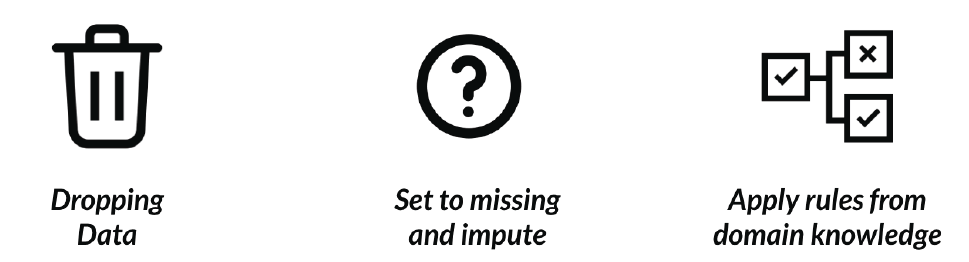

### **Exercise: How's our data integrity?**

You want to understand how customers of different age groups invest. You will do so by cross field checking values of `inv_amount` and `age` against the amount invested in different funds and customers' birthdays.

* Find the rows where the sum of all rows of the fund_columns in `banking` are equal to the `inv_amount` column.
* Store the values of `banking` with consistent `inv_amount` in `consistent_inv`, and those with inconsistent ones in `inconsistent_inv`.

In [ ]:
import pandas as pd
banking = pd.read_csv("banking_dirty.csv", index_col=[0])

# Store fund columns to sum against
fund_columns = ['fund_A', 'fund_B', 'fund_C', 'fund_D']

# Find rows where fund_columns row sum == inv_amount
inv_equ = banking[fund_columns].sum(axis=1) == banking["inv_amount"]

# Store consistent and inconsistent data
consistent_inv = banking[inv_equ]
inconsistent_inv = banking[~inv_equ]

# Store consistent and inconsistent data
print("Number of inconsistent investments: ", inconsistent_inv.shape[0])

Number of inconsistent investments:  8


* Store today's date into `today`, and manually calculate customers' ages and store them in `ages_manual`.
* Find all rows of `banking` where the age column is equal to `ages_manual` and then filter `banking` into `consistent_ages` and `inconsistent_ages`.

In [ ]:
import pandas as pd
import datetime as dt
banking = pd.read_csv("banking_dirty.csv", index_col=[0])
banking["birth_date"] = pd.to_datetime(banking["birth_date"])

# ไม่ตรงตามไฟล์ที่ให้ดาวน์โหลด
banking["Age"] = [59, 59, 31, 36, 37, 41, 50, 58, 46, 56, 39, 55, 37, 46, 43, 50, 43,
       38, 56, 28, 59, 59, 29, 53, 29, 37, 29, 40, 32, 32, 54, 34, 60, 40,
       35, 28, 37, 59, 32, 49, 48, 47, 38, 51, 29, 46, 32, 59, 58, 60, 42,
       50, 43, 29, 33, 30, 49, 47, 51, 53, 49, 46, 30, 46, 39, 55, 38, 31,
       54, 29, 33, 52, 49, 47, 34, 47, 45, 41, 47, 49, 51, 30, 48, 58, 48,
       47, 47, 53, 54, 53, 37, 47, 31, 58, 60, 47, 32, 37, 52, 28]

# Store today's date and find ages
today = dt.date.today()
ages_manual = today.year - banking["birth_date"].dt.year
# คนทำคอร์ส น่าจะแอบมาปรับคอลัมน์ age เพราะในไฟล์ข้อมูล ไม่ตรงกัน ณ ปี 2021

# Find rows where age column == ages_manual
age_equ = banking["Age"] == ages_manual

# Store consistent and inconsistent data
consistent_ages = banking[age_equ]
inconsistent_ages = banking[~age_equ]

# Store consistent and inconsistent data
print("Number of inconsistent ages: ", inconsistent_ages.shape[0])

Number of inconsistent ages:  4


There are only 8 and 4 rows affected by inconsistent `inv_amount` and `age` values, respectively. In this case, it's best to investigate the underlying data sources before deciding on a course of action!

# **Missing Values**

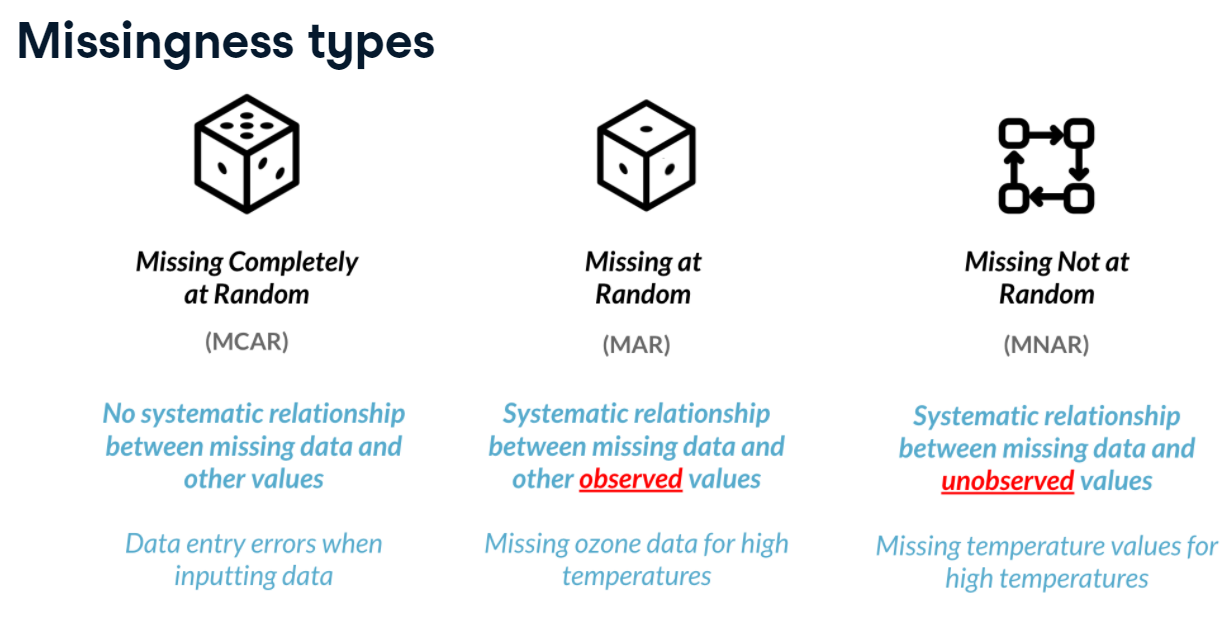



## **Missingno package**

Useful package for visualizing and understanding missing data

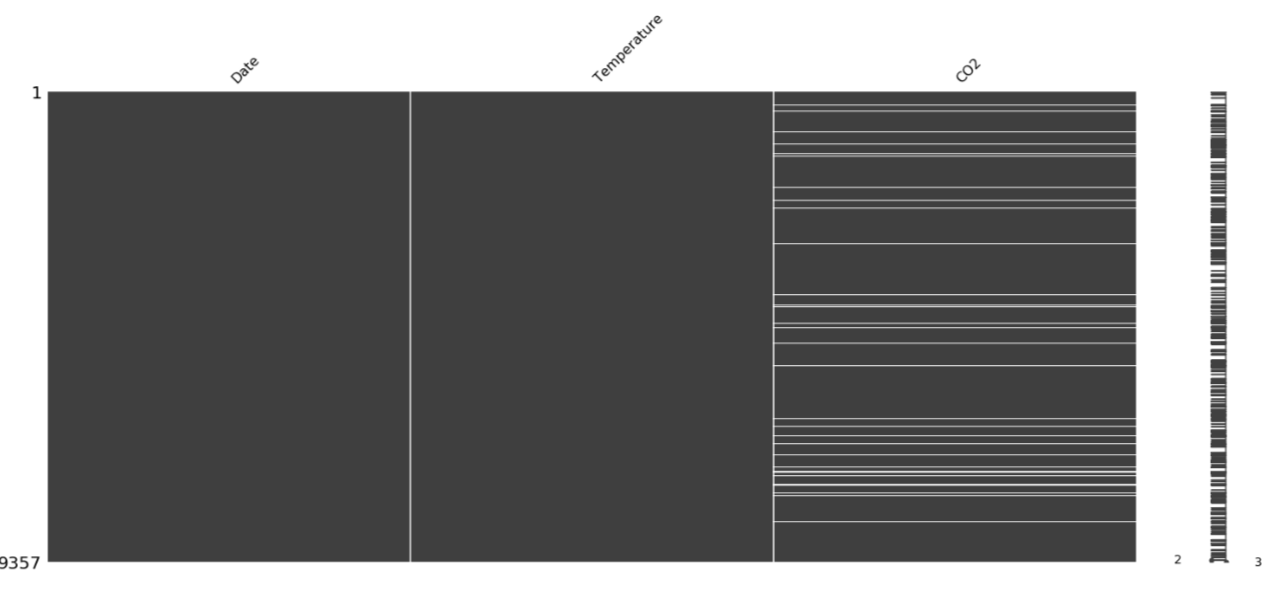

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

sorted_df = df.sort_values('Temperature')

# Visualize missingness
msno.matrix(sorted_df)
plt.show()

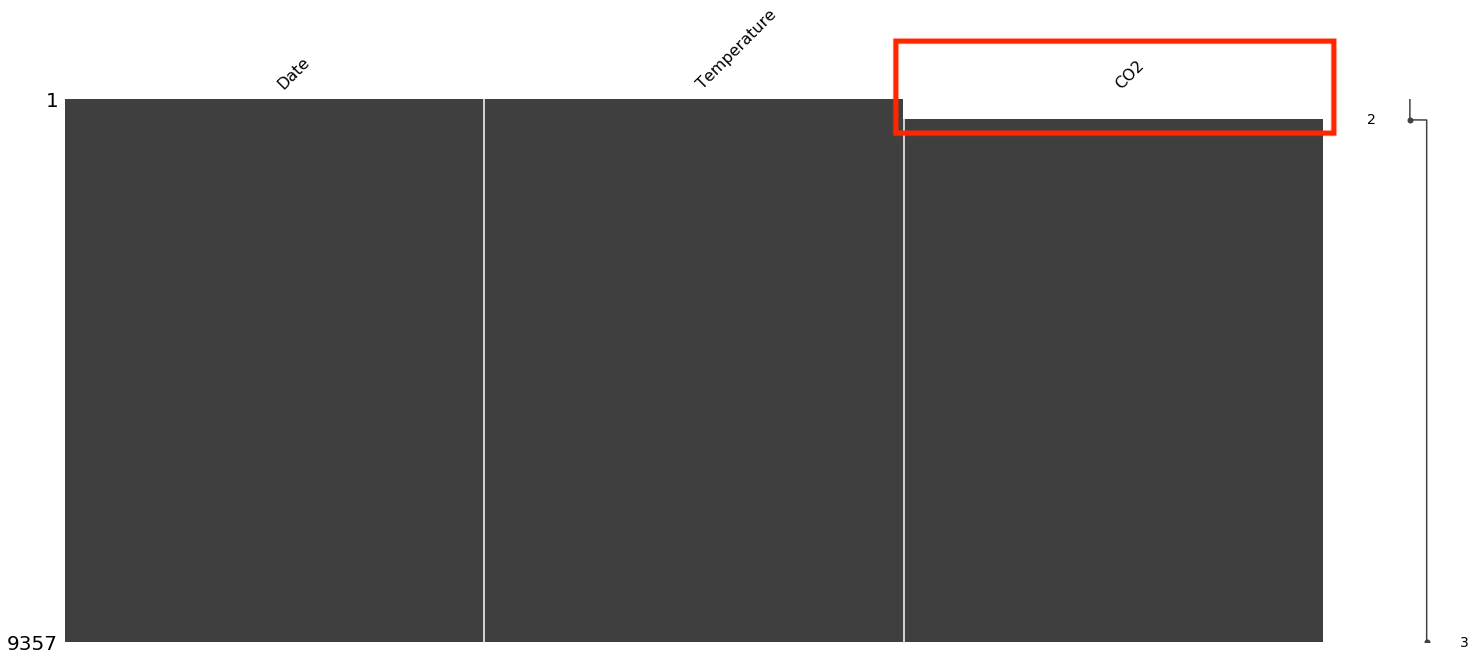

In [ ]:
sorted_df = df.sort_values('Temperature')
msno.matrix(sorted_df)
plt.show()

missing = df[df['CO2'].isnull()]
complete = df[df['CO2'].isnotnull()]

In the above CO2 is missing for a very low temperature.

**Complete**

```text
       Temperature          CO2
count   8991.000000  8991.000000
mean      18.317829     1.739584
std        8.832116     1.537580
min       -1.900000     0.000000
...             ...          ...
max       44.600000    11.900000
```

**Missing**

```text
       Temperature    CO2
count     366.000000    0.0
mean      -39.655738    NaN   <--
std         5.988716    NaN
min       -49.000000    NaN   <--
...              ...    ...
max       -30.000000    NaN   <--
```

## **Dropping missing values**

In [ ]:
df.dropna(subset=['col1'])

## **Replacing with aggregate values**

In [ ]:
df.fillna({'col1': df['col1'].mean()})

### **Exercise: Missing investors**

You know for a fact that most customers below `25` do not have investment accounts yet, and suspect it could be driving the missingness.

* Print the number of missing values by column in the `banking` DataFrame.
* Plot and show the missingness `matrix` of banking with the `msno.matrix()` function.
* Isolate the values of `banking` missing values of `inv_amount` into `missing_investors` and with non-missing `inv_amount` values into `investors`.

cust_id              0
age                  0
acct_amount          0
inv_amount          13
account_opened       0
last_transaction     0
dtype: int64


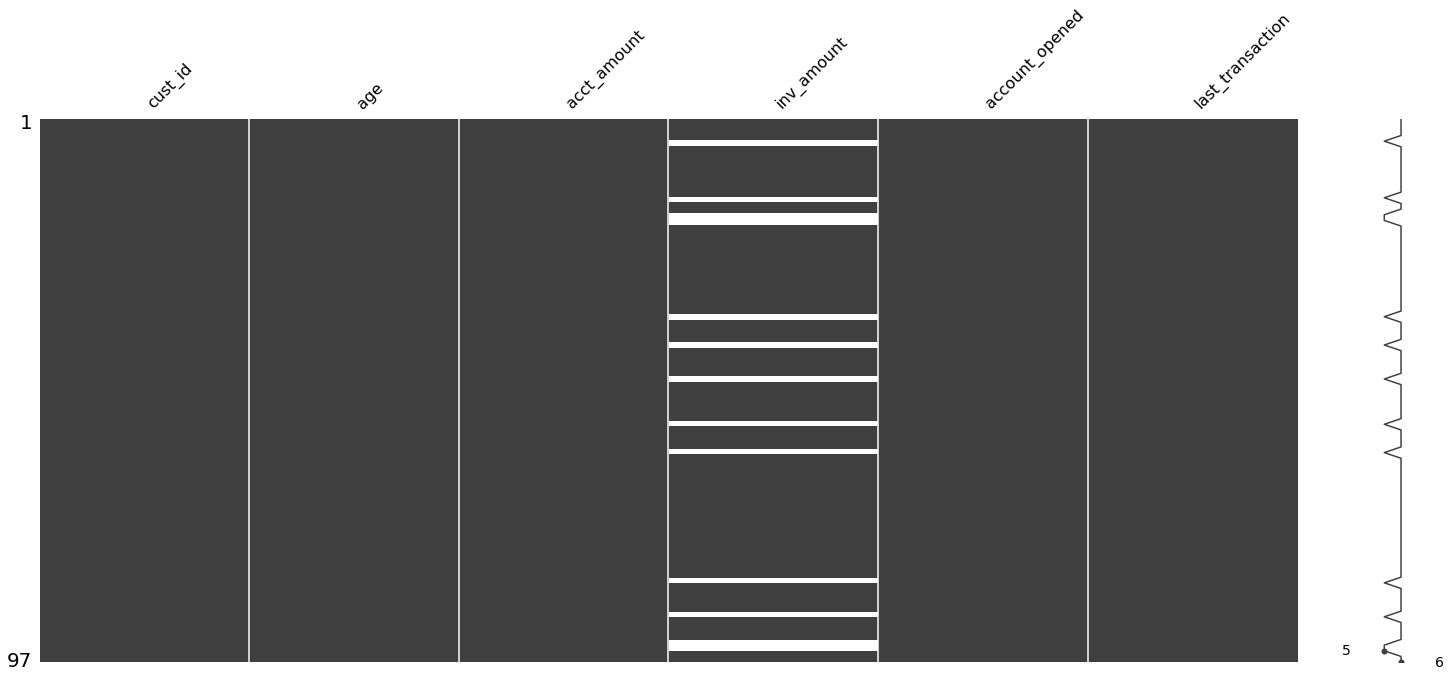

             age   acct_amount  inv_amount
count  13.000000     13.000000         0.0
mean   21.846154  73231.238462         NaN
std     1.519109  25553.327176         NaN
min    20.000000  21942.370000         NaN
25%    21.000000  66947.300000         NaN
50%    21.000000  86028.480000         NaN
75%    23.000000  89855.980000         NaN
max    25.000000  99998.350000         NaN 

              age    acct_amount    inv_amount
count  84.000000      84.000000     84.000000
mean   43.559524   75095.273214  44717.885476
std    10.411244   32414.506022  26031.246094
min    26.000000   12209.840000   3216.720000
25%    34.000000   57373.062500  22736.037500
50%    45.000000   83061.845000  44498.460000
75%    53.000000   94165.965000  66176.802500
max    59.000000  250046.760000  93552.690000


In [ ]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

banking = pd.read_csv("banking_with_missing.csv", index_col=[0])

# Print number of missing values in banking
print(banking.isna().sum())

# Visualize missingness matrix
msno.matrix(banking)
plt.show()

# Isolate missing and non missing values of inv_amount
missing_investors = banking[banking["inv_amount"].isna()]
investors = banking[~banking["inv_amount"].isna()]

print(missing_investors.describe(), "\n\n", investors.describe())

The `inv_amount` is missing only for young customers, since the average age in missing_investors is `21.846154` and the maximum age is `25`.

* Sort the `banking` DataFrame by the `age` column and plot the missingness matrix of `banking_sorted`.

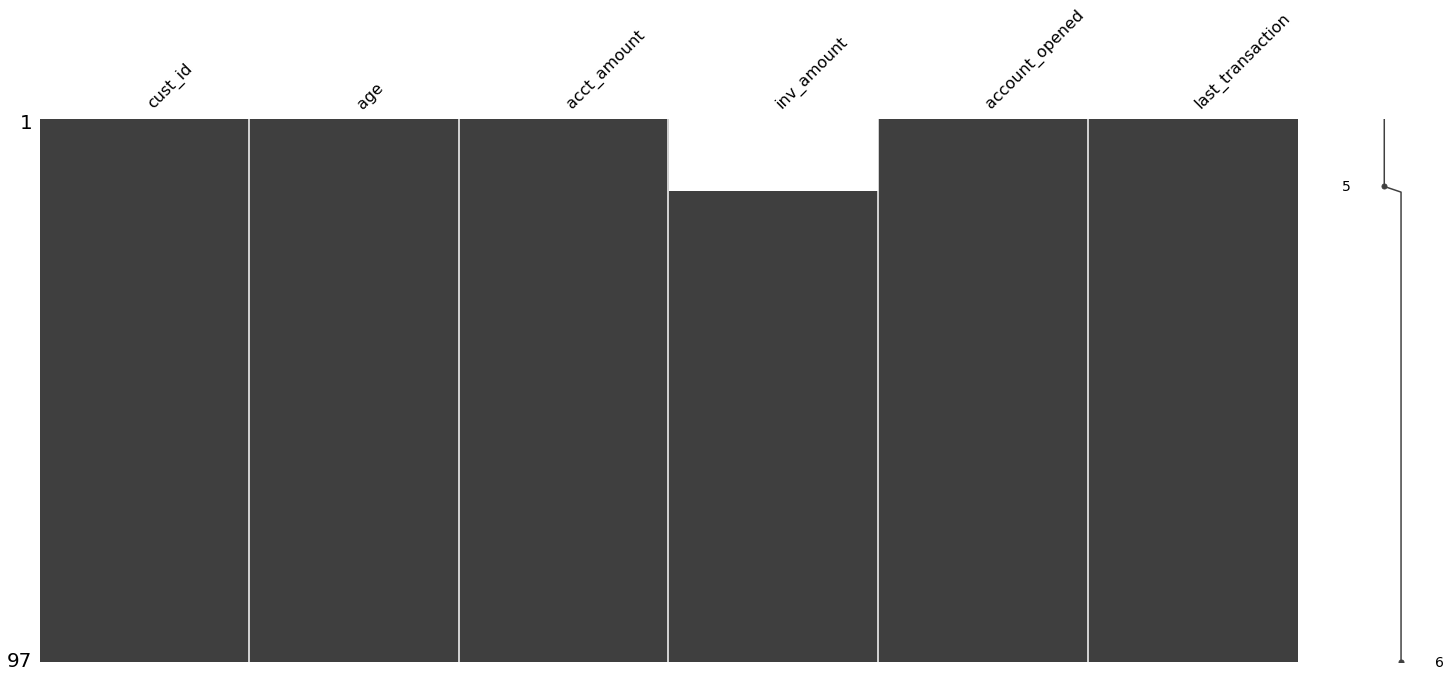

In [ ]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

banking = pd.read_csv("banking_with_missing.csv", index_col=[0])

# Isolate missing and non missing values of inv_amount
missing_investors = banking[banking['inv_amount'].isna()]
investors = banking[~banking['inv_amount'].isna()]

# Sort banking by age and visualize
banking_sorted = banking.sort_values(by="age")
msno.matrix(banking_sorted)
plt.show()

Notice how all the white spaces for `inv_amount` are on top? Indeed missing values are only due to young bank account holders not investing their money! Better set it to `0` with `.fillna()`.

### **Exercise: Follow the money**

You're working with another version of the `banking` DataFrame that contains missing values for both the `cust_id` column and the `acct_amount` column.

You know that rows with missing `cust_id` don't really help you, and that on average `acct_amount` is usually `5` times the amount of `inv_amount`.

You will drop rows of banking with missing `cust_ids`, and impute missing values of `acct_amount` with some domain knowledge.

* Use `.dropna()` to drop missing values of the `cust_id` column in banking and store the results in `banking_fullid`.
* Use `inv_amount` to compute the estimated account amounts for `banking_fullid` by setting the amounts equal to `inv_amount * 5`, and assign the results to `acct_imp`.
* Impute the missing values of `acct_amount` in `banking_fullid` with the newly created `acct_imp` using `.fillna()`.

In [ ]:
import pandas as pd
banking = pd.read_csv("banking_with_missing_cust_id_and_acct_amount.csv", index_col=[0])
print(banking.isnull().sum(), "\n\n")

# Drop missing values of cust_id
banking_fullid = banking.dropna(subset=["cust_id"])

# Compute estimated acct_amount
acct_imp = banking_fullid["inv_amount"]*5

# Impute missing acct_amount with corresponding acct_imp
banking_imputed = banking_fullid.fillna({'acct_amount':acct_imp})

# Print number of missing values
print(banking_imputed.isna().sum())

cust_id              9
acct_amount         14
inv_amount           0
account_opened       0
last_transaction     0
dtype: int64 


cust_id             0
acct_amount         0
inv_amount          0
account_opened      0
last_transaction    0
dtype: int64


# ***Record Linkage (This is unnecessary)***

# **Comparing Strings**

## **Minimum edit distance**

- The <u>least</u> possible amount of steps needed to transition from one string to another

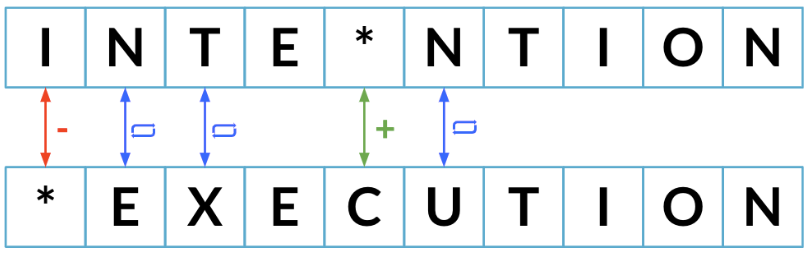

The example above has minimum edit distance equal 5.

## **String comparison (new)**

Use ***Levenshtein*** distance: ***Insertion***, ***substitution***, ***deletion***

- `0` not similar at all

- `100` is an exact match

In [ ]:
from thefuzz import fuzz

# Compare words
fuzz.WRatio('Reeding', 'Reading')

86

In [ ]:
fuzz.WRatio("Houston Rockets", "Rockets")

90

In [ ]:
fuzz.WRatio('Houston Rockets vs Los Angeles Lakers', 'Lakers vs Rockets')

86

## **Comparison with arrays of strings**

In [ ]:
from thefuzz import process
import pandas as pd

string = "Houston Rockets vs Los Angeles Lakers"
choices = pd.Series(["Rocket vs Lakers",
           "Lakers vs Rockets",
           "Houston vs Los Angeles",
           "Heat vs Bulls"])

process.extract(string, choices, limit=len(choices)) # ปกติจะให้ limit เท่ากับจำนวน choices

[('Rocket vs Lakers', 86, 0),
 ('Lakers vs Rockets', 86, 1),
 ('Houston vs Los Angeles', 86, 2),
 ('Heat vs Bulls', 86, 3)]

## **Collapsing categories with string similarity**

Previously above, we used **`.replace()`** to collapse `'eur'` to `'Europe'`.

When there are too many variations for manual replacement, e.g.,

`"EU"` , `"eur"` , `"Europ"` , `"Europa"` , `"Erope"` , `"Evropa"` ...

In [ ]:
# Example
print(df['state'].unique())

```text
id     state
0      California
1      Cali
2      Calefornia
3      Calefornie
4      Californie
5      Calfornia
6      Calefernia
7      New York
8      New York City
...
```



We want to collapse to


```
id   state
0    California
1    New York
```



## **Collapsing categories with string matching**

In [ ]:
survey = pd.DataFrame(data=['California', 'Cali', 'Calefornia', 'Calefornie', 'Californie', 'Calfornia', 'Calefernia', 'New York', 'New York City'], columns=['state'])
display(survey); print("\n")
categories = ['California', 'New York']

for state in categories:
    matches = process.extract(state, survey['state'], limit=survey.shape[0])
    display(matches); print("\n")

    for potential_match in matches:
        if potential_match[1] >= 80:
            survey.loc[survey['state']==potential_match[0], 'state'] = state

survey



,state
0,California
1,Cali
2,Calefornia
3,Calefornie
4,Californie
5,Calfornia
6,Calefernia
7,New York
8,New York City


[('California', 100, 0),
 ('Calfornia', 95, 5),
 ('Cali', 90, 1),
 ('Calefornia', 90, 2),
 ('Californie', 90, 4),
 ('Calefornie', 80, 3),
 ('Calefernia', 80, 6),
 ('New York City', 33, 8),
 ('New York', 22, 7)]

[('New York', 100, 7),
 ('New York City', 90, 8),
 ('California', 22, 0),
 ('California', 22, 1),
 ('California', 22, 2),
 ('California', 22, 3),
 ('California', 22, 4),
 ('California', 22, 5),
 ('California', 22, 6)]

,state
0,California
1,California
2,California
3,California
4,California
5,California
6,California
7,New York
8,New York


มันคือการเปลี่ยนแปลงค่าในตารางที่มีความใกล้เคียงกับค่าที่ต้องการจะเปลี่ยน (ตัดสินจากคะแนน)  เช่น Cali มาเปลี่ยนเป็นค่าที่ต้องการจะเปลี่ยน เป็น California

- ถ้าอย่างนั้นในตัวอย่างก่อนหน้านี้ Heat vs Bulls ได้คะแนน 86 ก็จะถูกเปลี่ยนมาเป็น "Houston Rockets vs Los Angeles Lakers" งั้นเหรอ?

    - ดูผลลัพธ์จากข้างล่างนี้เลย!

In [ ]:
survey = pd.DataFrame(data=["Rocket vs Lakers",
                            "Lakers vs Rockets",
                            "Houston vs Los Angeles",
                            "Heat vs Bulls"], columns=['state'])
display(survey); print("\n")

matches = process.extract("Houston Rockets vs Los Angeles Lakers", survey['state'], limit=len(survey))
display(matches); print("\n")

print(survey.loc[survey['state'] == "Heat vs Bulls"], '\n')

for match in matches:
    if match[1] >= 80:
        survey.loc[survey['state']==match[0], 'state'] = '555 What a lame package!'

survey



,state
0,Rocket vs Lakers
1,Lakers vs Rockets
2,Houston vs Los Angeles
3,Heat vs Bulls


[('Rocket vs Lakers', 86, 0),
 ('Lakers vs Rockets', 86, 1),
 ('Houston vs Los Angeles', 86, 2),
 ('Heat vs Bulls', 86, 3)]



           state
3  Heat vs Bulls 



,state
0,555 What a lame package!
1,555 What a lame package!
2,555 What a lame package!
3,555 What a lame package!


### **Exercise: The cutoff point**

`restaurants` dataframe has been collected from many sources, where the `cuisine_type` column is riddled with typos, and should contain only `italian`, `american` and `asian` cuisine types. There are so many unique categories that remapping them manually isn't scalable, and it's best to use string similarity instead.

Before doing so, you want to establish the cutoff point for the similarity score using the **`thefuzz.process.extract()`** function by finding the similarity score of the most distant typo of each category.

#### ***Instructions***

* Import `process` from `thefuzz`.
* Store the unique `cuisine_types` into `unique_types`.
* Calculate the similarity of `'asian'`, `'american'`, and `'italian'` to all possible `cuisine_types` using `process.extract()`, while returning all possible matches.

In [ ]:
import pandas as pd
from thefuzz import process
restaurants = pd.read_csv("restaurants.csv", index_col=[0])

# Store the unique values of cuisine_type in unique_types
unique_types = restaurants["cuisine_type"].unique()

# Calculate similarity of 'asian' to all values of unique_types
print(process.extract('asian', unique_types, limit=len(unique_types)))

# Calculate similarity of 'american' to all values of unique_types
print(process.extract('american', unique_types, limit=len(unique_types)))

# Calculate similarity of 'italian' to all values of unique_types
print(process.extract('italian', unique_types, limit=len(unique_types)))




[('asian', 100), ('asiane', 91), ('asiann', 91), ('asiian', 91), ('asiaan', 91), ('asianne', 83), ('asiat', 80), ('italiann', 72), ('italiano', 72), ('italianne', 72), ('italiaan', 68), ('italiian', 68), ('itallian', 68), ('italian', 67), ('amurican', 62), ('american', 62), ('ameerican', 60), ('aamerican', 60), ('ameriican', 60), ('amerrican', 60), ('ameerrican', 60), ('ammereican', 60), ('americann', 57), ('americano', 57), ('ammericann', 54), ('americin', 51), ('amerycan', 51), ('america', 50), ('merican', 50), ('murican', 50), ('italien', 50), ('americen', 46), ('itali', 40)]
[('american', 100), ('americann', 94), ('americano', 94), ('ameerican', 94), ('aamerican', 94), ('ameriican', 94), ('amerrican', 94), ('america', 93), ('merican', 93), ('ammericann', 89), ('ameerrican', 89), ('ammereican', 89), ('amurican', 88), ('americen', 88), ('americin', 88), ('amerycan', 88), ('murican', 80), ('asian', 62), ('asiane', 57), ('asiann', 57), ('asiian', 57), ('asiaan', 57), ('italian', 53), (

80 is that sweet spot where you convert all incorrect typos without remapping incorrect categories. Often times though, you may need to combine the techniques learned above, especially since there could be strings that make it beyond our cutoff point, but are not actually a match!

### **Exercise: Remapping categories II**

Above, the distance cutoff point for remapping typos of `'american'`, `'asian'`, and `'italian'` cuisine types stored in the `cuisine_type` column should be `80`.

You are to find matches with similarity scores equal to or higher than `80` by using **`thefuzz.process.extract()`** function, for each correct cuisine type, and replacing these matches with it. Remember, when comparing a string with an array of strings using **`process.extract()`**, the output is a list of tuples where each is formatted like:

`(closest match, similarity score, index of match)`

* Return all of the unique values in the `cuisine_type` column of restaurants.

In [ ]:
import pandas as pd
restaurants = pd.read_csv("restaurants.csv", index_col=[0])

# Inspect the unique values of the cuisine_type column
print(restaurants["cuisine_type"].unique())



['america' 'merican' 'amurican' 'americen' 'americann' 'asiane' 'itali'
 'asiann' 'murican' 'italien' 'italian' 'asiat' 'american' 'americano'
 'italiann' 'ameerican' 'asianne' 'italiano' 'americin' 'ammericann'
 'amerycan' 'aamerican' 'ameriican' 'italiaan' 'asiian' 'asiaan'
 'amerrican' 'ameerrican' 'ammereican' 'asian' 'italianne' 'italiian'
 'itallian']


*  Create a list of all possible `matches`, comparing `'italian'` with the restaurant types listed in the `cuisine_type` column.

In [ ]:
import pandas as pd
from thefuzz import process
restaurants = pd.read_csv("restaurants.csv", index_col=[0])
# Create a list of matches, comparing 'italian' with the cuisine_type column
matches = process.extract("italian", restaurants["cuisine_type"], limit=restaurants.shape[0])

# Inspect the first 5 matches
print(matches[0:5])

[('italian', 100, 11), ('italian', 100, 24), ('italian', 100, 37), ('italian', 100, 43), ('italian', 100, 44)]


* Within the `for` loop, use an `if` statement to check whether the similarity score in each `match` is greater than or equal to `80`.
* If it is, use `.loc` to select rows where `cuisine_type` in `restaurants` is equal to the current match (which is the first element of `match`), and reassign them to be `'italian'`.

In [ ]:
import pandas as pd
from thefuzz import process
restaurants = pd.read_csv("restaurants.csv", index_col=[0])

# Create a list of matches, comparing 'italian' with the cuisine_type column
matches = process.extract('italian', restaurants['cuisine_type'], limit=len(restaurants.cuisine_type))

# Iterate through the list of matches to italian
for match in matches:
    # Check whether the similarity score is greater than or equal to 80
    if match[1] >= 80:
        # Select all rows where the cuisine_type is spelled this way, and set them to the correct cuisine
        restaurants.loc[restaurants["cuisine_type"]==match[0], "cuisine_type"] = 'italian'

* Using the variable `cuisine` to iterate through `categories`, embed your code from the previous step in an outer `for` loop.

In [ ]:
import pandas as pd
from thefuzz import process
restaurants = pd.read_csv("restaurants.csv", index_col=[0])
categories = ['italian', 'asian', 'american']

#Before modification
print(restaurants["cuisine_type"].unique(),"\n\n")

# Iterate through categories
for cuisine in categories:
  # Create a list of matches, comparing cuisine with the cuisine_type column
  matches = process.extract(cuisine, restaurants['cuisine_type'], limit=len(restaurants.cuisine_type))

  # Iterate through the list of matches
  for match in matches:
     # Check whether the similarity score is greater than or equal to 80
    if match[1] >= 80:
      # If it is, select all rows where the cuisine_type is spelled this way, and set them to the correct cuisine
      restaurants.loc[restaurants['cuisine_type']==match[0], 'cuisine_type'] = cuisine

# Inspect the final result
print("After modification:\n", restaurants['cuisine_type'].unique())

['america' 'merican' 'amurican' 'americen' 'americann' 'asiane' 'itali'
 'asiann' 'murican' 'italien' 'italian' 'asiat' 'american' 'americano'
 'italiann' 'ameerican' 'asianne' 'italiano' 'americin' 'ammericann'
 'amerycan' 'aamerican' 'ameriican' 'italiaan' 'asiian' 'asiaan'
 'amerrican' 'ameerrican' 'ammereican' 'asian' 'italianne' 'italiian'
 'itallian'] 


After modification:
 ['american' 'asian' 'italian']


,rest_name,rest_addr,city,phone,cuisine_type
0,arnie morton s of chicago,435 s. la cienega blv .,los angeles,3102461501,american
1,art s delicatessen,12224 ventura blvd.,studio city,8187621221,american
2,campanile,624 s. la brea ave.,los angeles,2139381447,american
3,fenix,8358 sunset blvd. west,hollywood,2138486677,american
4,grill on the alley,9560 dayton way,los angeles,3102760615,american


# **Record Linkage**

When Python's <u>joins won't work</u> due to different names for the same events.  Record linkage does not require exact matches between different pairs of data, and instead can find close matches using string similarity.

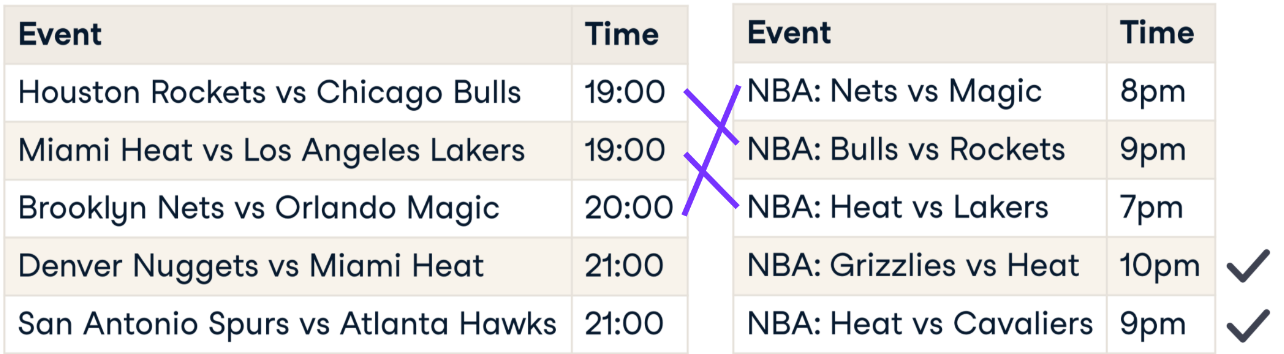



## **Blocking**

- If we generate all pairs, they are too many

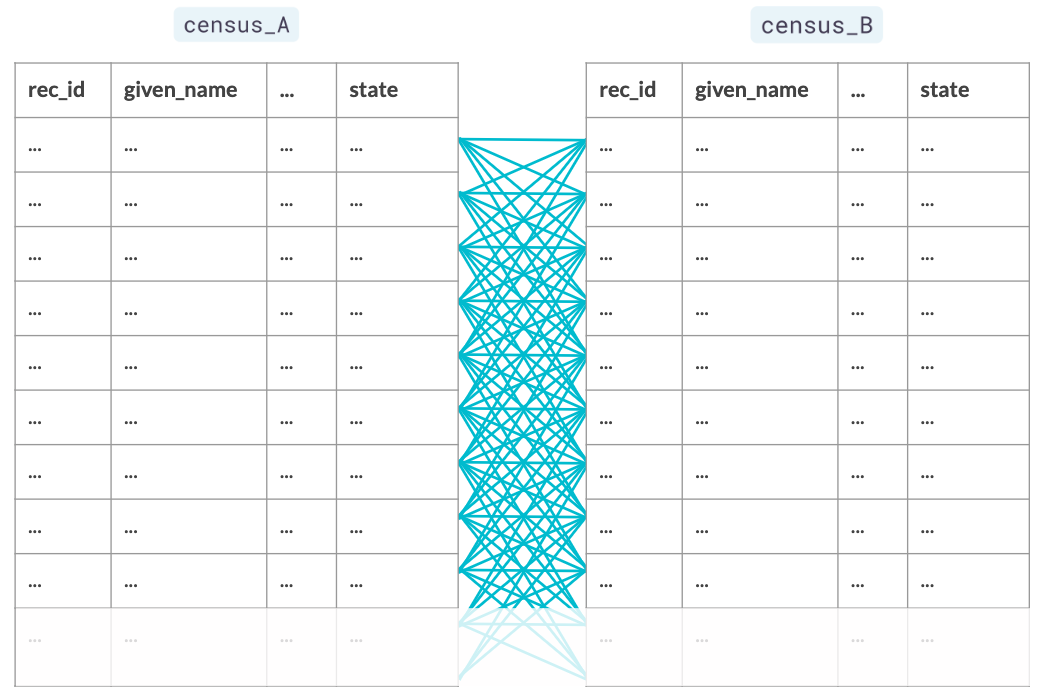

- We use "blocking" based on matching column

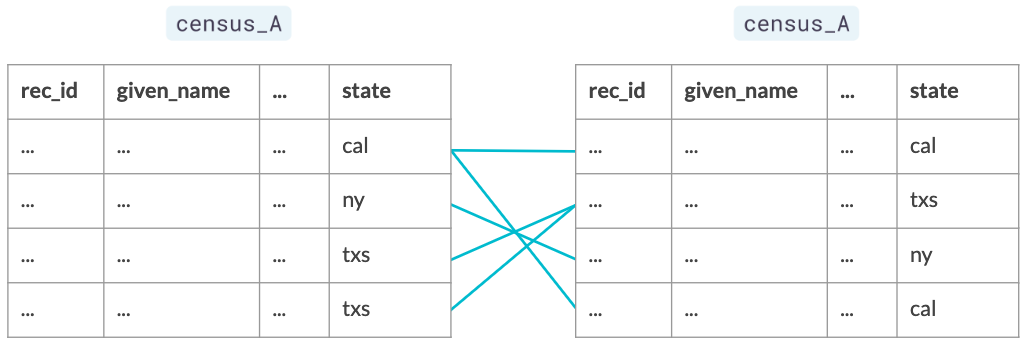

## **Generating Pairs**

Unlike joins, `recordlinkage` does not require exact matches between different pairs of data, and instead can find close matches using string similarity. This is why `recordlinkage` is effective when there are no common unique keys between the data sources.

In [ ]:
import recordlinkage

df1 = pd.read_csv('file1.csv')
df2 = pd.read_csv('file2.csv')

# Create indexing object
indexer = recordlinkage.Index()

# Generate paired blocks on column of interest
indexer.block("col_name")
pairs = indexer.index(df1, df2)

## **Compare dataframes**

In [ ]:
# Create a Compare object
pairs = indexer.index(df1, df2)
compare_cl = recordlinkage.Compare()

# Find EXACT matches for pairs of col_name1 and col_name2
compare_cl.exact("col_name1", "col_name1", label="col_name1")
compare_cl.exact("col_name2", "col_name2", label="col_name2")

# Find similar matches (not exact) for fuzzying columns 1 and 2
compare_cl.string("fuzzy_col1", "fuzzy_col1", threshold=0.85, label="fuzzy_col1")
compare_cl.string("fuzzy_col2", "fuzzy_col2", threshold=0.85, label="fuzzy_col2")

# Find matches
potential_matches = compare_cl.compute(pairs, df1, df2)
potential_matches[potential_matches.sum(axis=1) >= 2]

## **Census Example**

`census_A`
```text
             given_name  surname   date_of_birth      suburb         state  address_1
rec_id
rec-1070-org  michaela   neumann      19151111   winston hills      cal     stanley street
rec-1016-org  courtney   painter      19161214       richlands      txs   pinkerton circuit
...
```

`census_B`

```text
             given_name  surname  date_of_birth      suburb    state  address_1
rec_id
rec-561-dup-0   elton      NaN      19651013   windermere       ny  light setreet
rec-2642-dup-0 mitchell   maxon      19390212   north ryde      cal  edkins street
...
```

We decide to use a column "state" as block since it seems to have least discrepancy.

In [ ]:
# Generating pairs
from recordlinkage import Index, Compare

census_A, census_B = pd.read_csv('census_A'), pd.read_csv('census_B')

indexer = Index()
indexer.block('state')
pairs = indexer.index(census_A, census_B)

print(pairs)

```text
MultiIndex(
    levels=[
        ['rec-1007-org', 'rec-1016-org', 'rec-1054-org', 'rec-1066-org',
         'rec-1070-org', 'rec-1075-org', 'rec-1080-org', 'rec-110-org',
         'rec-1146-org', 'rec-1157-org', 'rec-1165-org', 'rec-1185-org',
         'rec-1234-org', 'rec-1271-org', 'rec-1280-org', ...],
        [66, 14, 13, 18, 34, 39, 0, 16, 80, 50, 20, 69, 28, 25, 49, 77,
         51, 85, 52, 63, 74, 61, 83, 91, 22, 26, 55, 84, 11, 81, 97,
         56, 27, 48, 2, 64, 5, 17, 29, 60, 72, 47, 92, 12, 95, 15,
         19, 57, 37, 70, 94]
    ],
    names=['rec_id_1', 'rec_id_2']
)
```

In [ ]:
# Compare dataframes
pairs = indexer.index(census_A, census_B)

compare_cl = Compare()

compare_cl.exact('date_of_birth', 'date_of_birth', label='date_of_birth')
compare_cl.exact('state', 'state', label='state')
compare_cl.string('sur_name', 'sur_name', threshold=0.85, label='surname')
compare_cl.string('address_1', 'address_1', threshold=0.85, label='address_1')

potential_matches = compare_cl.compute(pairs, census_A, census_B)

print(potential_matches)

```text
                              date_of_birth  state  surname  address_1
rec_id_1        rec_id_2
rec-1070-org    rec-561-dup-0        0          1      0.0       0.0
                rec-2642-dup-0       0          1      0.0       0.0
                rec-608-dup-0        0          1      0.0       0.0
                ...
rec-1631-org    rec-4070-dup-0       0          1      0.0       0.0
                rec-4862-dup-0       0          1      0.0       0.0
                rec-629-dup-0        0          1      0.0       0.0
                ...
```

In [ ]:
potential_matches[potential_matches.sum(axis = 1) >= 2]

```text
                              date_of_birth  state  surname  address_1
rec_id_1        rec_id_2
rec-4878-org    rec-4878-dup-0       1          1      1.0       0.0
rec-417-org     rec-2867-dup-0       0          1      0.0       1.0
rec-3964-org    rec-394-dup-0        0          1      1.0       0.0
rec-1373-org    rec-4051-dup-0       0          1      1.0       0.0
                rec-802-dup-0        0          1      1.0       0.0
rec-3540-org    rec-470-dup-0        0          1      1.0       0.0
```

The higher the sum of each row, the closer the match

### ***Exercise: To link or not to link?***

Similar to joins, <u>***record linkage***</u> is the act of linking data from different sources regarding the same entity. But unlike joins, record linkage <u>*does not require exact matches*</u> between different pairs of data, and instead can find close matches using string similarity. This is why record linkage is <u>*effective when there are no common unique keys*</u> between the data sources you can rely upon when linking data sources such as a unique identifier.

In this exercise, you will classify whether it is a traditional join problem, or a record linkage one.

- Two basketball dataframes with a common unique identifier per game
  - Join
- Consolidating two dataframes containing details on DataCamp courses with each DataCamp course having its own unique identifier
  - Join
- Merging two basketball dataframes with column `team_A`, `team_B`, and `time` and differently formatted team names between each dataframe
  - Record Linkage
- 2 customer dataframes containing names and addresses, one with a unique identifier per customer, one without
  - Record Linkage
- Using `address` column to join two dataframes, with the address in each dataframe being formatted slightly differently
  - Record Linkage

### **Exercise: Pairs of restaurants**

There are duplicates with typos in restaurants names that require record linkage instead of joins.

* Instantiate an indexing object by using the `Index()` function from `recordlinkage`.
* Block your pairing on `cuisine_type` by using `indexer`'s' .`block()` method.
* Generate pairs by indexing `restaurants` and `restaurants_new` in that order.

In [ ]:
import pandas as pd
import recordlinkage

restaurants = pd.read_csv("restaurants_L2.csv", index_col=[0])
restaurants_new = pd.read_csv("restaurants_L2_dirty.csv", index_col=[0])
restaurants.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
restaurants_new.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]

# Create an indexer and object and find possible pairs
indexer = recordlinkage.Index()

# Block pairing on cuisine_type
indexer.block("cuisine_type")

# Generate pairs
pairs = indexer.index(restaurants, restaurants_new)

### **Exercise: Similar restaurants**

When performing `recordlinkage`, there are different types of matching you can perform between different columns of your DataFrames, including exact matches, string similarities, and more.

Now that your pairs have been generated and stored in `pairs`, you will find exact matches in the `city` and `cuisine_type` columns between each pair, and similar strings for each pair in the `rest_name` column.

* Instantiate a comparison object using the `recordlinkage.Compare()` function.
* Use the appropriate `comp_cl` method to find exact matches between the `city` and `cuisine_type` columns of both DataFrames.
* Use the appropriate `comp_cl` method to find similar strings with a `0.8` similarity threshold in the `rest_name` column of both DataFrames.
* Compute the comparison of the pairs by using the `.compute()` method of `comp_cl`.

In [ ]:
import pandas as pd
import recordlinkage

restaurants = pd.read_csv("restaurants_L2.csv", index_col=[0])
restaurants_new = pd.read_csv("restaurants_L2_dirty.csv", index_col=[0])
restaurants.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
restaurants_new.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
indexer = recordlinkage.Index()
indexer.block("cuisine_type")
pairs = indexer.index(restaurants, restaurants_new)

# Create a comparison object
comp_cl = recordlinkage.Compare()

# Find exact matches on city, cuisine_types
comp_cl.exact('city', 'city', label='city')
comp_cl.exact('cuisine_type', 'cuisine_type', label='cuisine_type')

# Find similar matches of rest_name
comp_cl.string('rest_name', 'rest_name', label='name', threshold=0.8)

# Get potential matches and print
potential_matches = comp_cl.compute(pairs, restaurants, restaurants_new)
print(potential_matches.head(30), "\n\n")
print(potential_matches[potential_matches.sum(axis=1) >= 3])

      city  cuisine_type  name
0 0      0             1   0.0
  1      0             1   0.0
  7      0             1   0.0
  12     0             1   0.0
  13     0             1   0.0
  20     0             1   0.0
  27     0             1   0.0
  28     0             1   0.0
  39     0             1   0.0
  40     1             1   1.0
  43     1             1   0.0
  49     0             1   0.0
  50     1             1   0.0
  51     0             1   0.0
  53     1             1   0.0
  54     0             1   0.0
  61     0             1   0.0
  67     0             1   0.0
  74     1             1   0.0
  81     0             1   0.0
1 0      0             1   0.0
  1      0             1   0.0
  7      0             1   0.0
  12     0             1   0.0
  13     0             1   0.0
  20     0             1   0.0
  27     0             1   0.0
  28     1             1   1.0
  39     0             1   0.0
  40     0             1   0.0 


       city  cuisine_type  name
0  4

* The columns in `potential_matches` are the columns being compared, with values being `1` for a match, and `0` for not a match for each pair of rows in your DataFrames. To find potential matches, you need to find rows with more than matching value in a column. You can find them with

```
potential_matches[potential_matches.sum(axis = 1) >= n]
```

* You want the above to have threshold n=3 since `city` and `cuisine_type` were exact matches and `name`s were similar matches.

  * If n=2, then you will get duplicates for all restaurants with the same cuisine type in the same city.
  * If n=1, what if you had restaurants with the same name in different cities?

* ตัวที่มัน match หมายความว่า มันน่าจะเป็นค่า duplicates นะ !!

* ก่อนจะเอา ตาราง มาต่อกัน ต้องจัดการแถวที่คาดว่าน่าจะเป็น duplicates ออกไปก่อน

* tightening your selection criteria will ensure good duplicate finds

## **Linking dataframes**

#### **What have been done**

In [ ]:
# Import recordlinkage and generate full pairs
import recordlinkage

indexer = recordlinkage.Index()
indexer.block('state')
full_pairs = indexer.index(census_A, census_B)

# Comparison step
compare_cl = recordlinkage.Compare()
compare_cl.exact('date_of_birth', 'date_of_birth', label='date_of_birth')
compare_cl.exact('state', 'state', label='state')
compare_cl.string('surname', 'surname', threshold=0.85, label='surname')
compare_cl.string('address_1', 'address_1', threshold=0.85, label='address_1')

potential_matches = compare_cl.compute(full_pairs, census_A, census_B)

#### **Potential matches table**

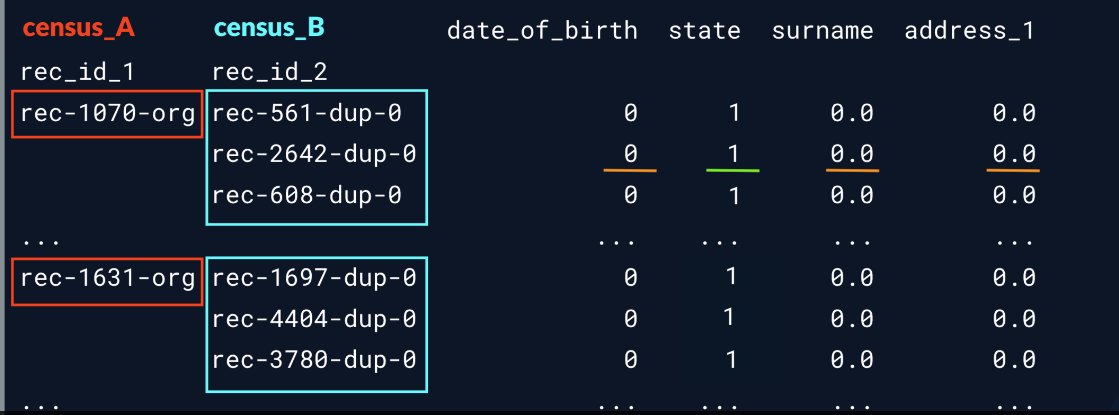

The second index column stores all potential indices from `census_B` for each row index of `census_A`

In [ ]:
# Find most likely matches
matches = potential_matches[potential_matches.sum(axis=1) >= 3]
print(matches)

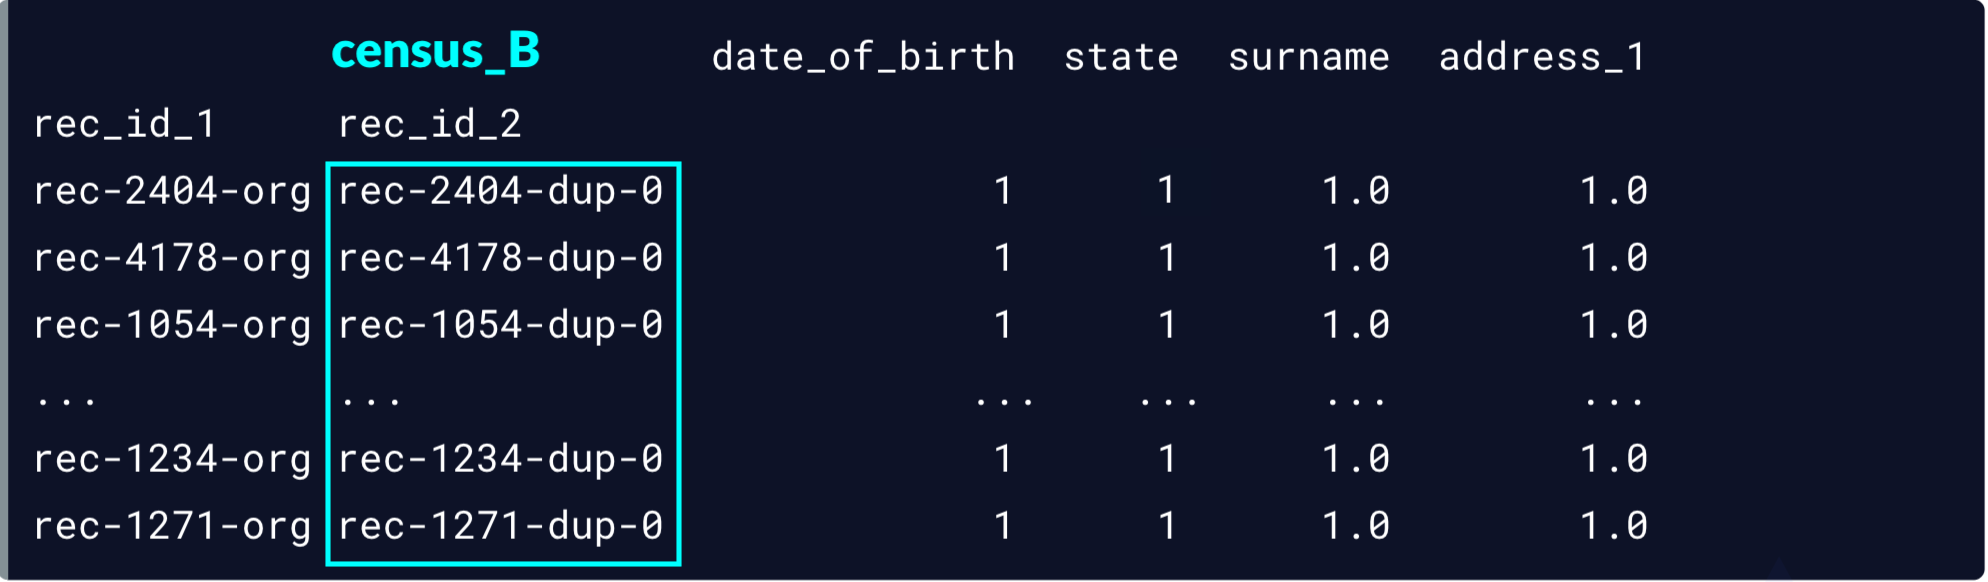

This table have rows indices between census A and census B that are most likely duplicates.

## **Get the indices**

In [ ]:
matches.index

```
MultiIndex(levels=[['rec-1007-org', 'rec-1016-org', 'rec-1054-org', 'rec-1066-org',
'rec-1070-org', 'rec-1075-org', 'rec-1080-org', 'rec-110-org', ...
```

## **Get indices from census B only**

In [ ]:
# Get indices from census_B only
duplicate_rows = matches.index.get_level_values(1)
print(duplicate_rows)

```
Index(['rec-2404-dup-0', 'rec-4178-dup-0', 'rec-1054-dup-0', 'rec-4663-dup-0',
'rec-485-dup-0', 'rec-2950-dup-0', 'rec-1234-dup-0', ... , 'rec-299-dup-0'])
```

## **Linking DataFrames**

In [ ]:
# Finding duplicates in census_B
census_B_duplicates = census_B[census_B.index.isin(duplicate_rows)]

# Finding new rows in census_B that are not duplicates
census_B_new = census_B[~census_B.index.isin(duplicate_rows)]

# เอา census B ที่เอาค่าซ้ำออกไปแล้วมาต่อกับ census A
full_census = pd.concat([census_A, census_B_new])

## **Summarizing steps**



In [ ]:
from recordlinkage import Index, Compare

indexer = Index()
indexer.block('state')
full_pairs = indexer.index(census_A, census_B)
compare_cl = Compare()
potential_matches = compare_cl.compute(full_pairs, census_A, census_B)
matches = potential_matches[potential_matches.sum(axis=1) >= 3]
duplicate_rows = matches.index.get_level_values(1)
census_B_new = census_B[~census_B.index.isin(duplicate_rows)]
full_census = pd.concat([census_A, census_B_new])


### ***Exercise: Getting the right index***

Here's a DataFrame named `matches` containing potential matches between two DataFrames, `users_1` and `users_2`. Each DataFrame's row indices is stored in `uid_1` and `uid_2` respectively.
```text
             first_name  address_1  address_2  marriage_status  date_of_birth
uid_1 uid_2
0     3               1          1          1                 1              0
      ...           ...        ...        ...               ...            ...
      ...           ...        ...        ...               ...            ...
1     3               1          1          1                 1              0
      ...           ...        ...        ...               ...            ...
      ...           ...        ...        ...               ...            ...
```

How do you extract all values of the uid_1 index column?

- `matches.index.get_level_values(0)` or `matches.index.get_level_values('uid_1')`

### **Exercise: Linking them together!**

To link both DataFrames, you will do so by first extracting all row indices of `restaurants_new` that are matching across the columns `"cuisine_type"`, `"city"`, and `"rest_name"` from `potential_matches`. Then you will subset `restaurants_new` on these indices, then append the non-duplicate values to `restaurants`.

* Isolate instances of `potential_matches` where the row sum is above or equal to `3` by using the `.sum()` method.
* Extract the second column index from `matches`, which represents row indices of matching record from `restaurants_new` by using the `.get_level_values()` method.
* Subset `restaurants_new` for rows that are not in `matching_indices`.
* Append `non_dup` to `restaurants`.

In [ ]:
import pandas as pd
import recordlinkage
pd.set_option("display.max_rows", None)

restaurants = pd.read_csv("restaurants_L2.csv", index_col=[0])
restaurants_new = pd.read_csv("restaurants_L2_dirty.csv", index_col=[0])
restaurants.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
restaurants_new.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
indexer = recordlinkage.Index()
indexer.block("cuisine_type")
pairs = indexer.index(restaurants, restaurants_new)
comp_cl = recordlinkage.Compare()
comp_cl.exact('city', 'city', label='city')
comp_cl.exact('cuisine_type', 'cuisine_type', label='cuisine_type')
comp_cl.string('rest_name', 'rest_name', label='name', threshold=0.8)
potential_matches = comp_cl.compute(pairs, restaurants, restaurants_new)

# Isolate potential matches with row sum >=3
matches = potential_matches[potential_matches.sum(axis=1) >= 3]

# Get values of second column index of matches
matching_indices = matches.index.get_level_values(1)

# Subset restaurants_new based on non-duplicate values
non_dup = restaurants_new[~restaurants_new.index.isin(matching_indices)]

# Append non_dup to restaurants
full_restaurants = restaurants.append(non_dup).reset_index(drop=True) # append id deprecated
print(full_restaurants)

                                         rest_name  \
0                        arnie morton's of chicago   
1                               art's delicatessen   
2                                        campanile   
3                                            fenix   
4                               grill on the alley   
5                                 restaurant katsu   
6                                   locanda veneta   
7                                        matsuhisa   
8                                         the palm   
9                          philippe's the original   
10                               rex il ristorante   
11                                       valentino   
12           yujean kang's gourmet chinese cuisine   
13                                         21 club   
14                                         aureole   
15                                       cafe lalo   
16                                       carmine's   
17                          

#### **Put everything together to make sure this works**

In [3]:
import pandas as pd
import recordlinkage
pd.set_option("display.max_rows", None)

restaurants = pd.read_csv("restaurants_L2.csv", index_col=[0])
restaurants_new = pd.read_csv("restaurants_L2_dirty.csv", index_col=[0])
restaurants.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
restaurants_new.columns = ["rest_name", "rest_addr", "city", "phone", "cuisine_type"]
indexer = recordlinkage.Index()
indexer.block("cuisine_type")
pairs = indexer.index(restaurants, restaurants_new)
comp_cl = recordlinkage.Compare()
comp_cl.exact('city', 'city', label='city')
comp_cl.exact('cuisine_type', 'cuisine_type', label='cuisine_type')
comp_cl.string('rest_name', 'rest_name', label='name', threshold=0.8)
potential_matches = comp_cl.compute(pairs, restaurants, restaurants_new)

# Isolate potential matches with row sum >=3
matches = potential_matches[potential_matches.sum(axis=1) >= 3]

# Get values of second column index of matches
matching_indices = matches.index.get_level_values(1)

# Subset restaurants_new based on non-duplicate values
non_dup = restaurants_new[~restaurants_new.index.isin(matching_indices)]

# Append non_dup to restaurants
full_restaurants = pd.concat([restaurants, non_dup]).reset_index(drop=True)
full_restaurants.head(10)

,rest_name,rest_addr,city,phone,cuisine_type
0,arnie morton's of chicago,435 s. la cienega blv .,los angeles,3102461501,american
1,art's delicatessen,12224 ventura blvd.,studio city,8187621221,american
2,campanile,624 s. la brea ave.,los angeles,2139381447,american
3,fenix,8358 sunset blvd. west,hollywood,2138486677,american
4,grill on the alley,9560 dayton way,los angeles,3102760615,american
5,restaurant katsu,1972 n. hillhurst ave.,los angeles,2136651891,asian
6,locanda veneta,3rd st.,los angeles,3102741893,italian
7,matsuhisa,129 n. la cienega blvd.,beverly hills,3106599639,asian
8,the palm,9001 santa monica blvd.,los angeles,3105508811,american
9,philippe's the original,1001 n. alameda st.,los angeles,2136283781,american
